# 1) Importing the needed packages

In [1]:
from pyspark.sql import SparkSession
from pyspark.sql.functions import col, count as _count, countDistinct, min as spark_min, max as spark_max, when, isnan, isnull, when, desc, lit, length, trim, lower, current_date, sum as _sum , year, month, date_format
import re
import seaborn as sns
import matplotlib.pyplot as plt
import pandas as pd

StatementMeta(, b16d20db-fce4-4a35-a222-b6b0a657bd8a, 3, Finished, Available, Finished, False)

# 2) Reading raw data

In [2]:
spark = SparkSession.getActiveSession()
if spark is None:
    spark = SparkSession.builder.appName("AB_NYC_EDA").getOrCreate()

# ============================================================================
# READ FROM BRONZE DELTA TABLE
# ============================================================================
df = spark.table("Bronze.AB_NYC_2019")

print(f"✅ Data loaded successfully from Bronze")

StatementMeta(, fd79048c-81d6-4492-91c4-8f66a9dcc85d, 4, Finished, Available, Finished, False)

✅ Data loaded successfully from Bronze


# 3) General Exploration

In [3]:
# Head - first 5 rows
print("\n📋 First 5 rows:")
display(df.limit(5))

StatementMeta(, d9fedb96-84b6-4dce-adf5-c89b6d485b09, 5, Finished, Available, Finished, False)


📋 First 5 rows:


SynapseWidget(Synapse.DataFrame, 3790052c-63f1-438f-a670-2059f2065a06)

In [4]:
# Tail - last 5 rows
print("\n📋 Last 5 rows:")
display(df.orderBy(col("id").desc()).limit(5))

StatementMeta(, d9fedb96-84b6-4dce-adf5-c89b6d485b09, 6, Finished, Available, Finished, False)


📋 Last 5 rows:


SynapseWidget(Synapse.DataFrame, c5607e93-7ce8-41fe-81d6-7c2860522c4b)

In [5]:
# Info - schema and counts
print("\n📋 Schema Info:")
df.printSchema()

print(f"\n📊 Dataset Info:")
print(f"   Total rows: {df.count():,}")
print(f"   Total columns: {len(df.columns)}")

# Missing values summary
print(f"\n📊 Missing Values:")
for c in df.columns:
    null_count = df.filter(col(c).isNull()).count()
    if null_count > 0:
        print(f"   {c}: {null_count:,} nulls ({null_count/df.count()*100:.1f}%)")

StatementMeta(, d9fedb96-84b6-4dce-adf5-c89b6d485b09, 7, Finished, Available, Finished, False)


📋 Schema Info:
root
 |-- id: integer (nullable = true)
 |-- name: string (nullable = true)
 |-- host_id: integer (nullable = true)
 |-- host_name: string (nullable = true)
 |-- neighbourhood_group: string (nullable = true)
 |-- neighbourhood: string (nullable = true)
 |-- latitude: double (nullable = true)
 |-- longitude: double (nullable = true)
 |-- room_type: string (nullable = true)
 |-- price: integer (nullable = true)
 |-- minimum_nights: integer (nullable = true)
 |-- number_of_reviews: integer (nullable = true)
 |-- last_review: date (nullable = true)
 |-- reviews_per_month: double (nullable = true)
 |-- calculated_host_listings_count: integer (nullable = true)
 |-- availability_365: integer (nullable = true)


📊 Dataset Info:
   Total rows: 48,895
   Total columns: 16

📊 Missing Values:
   name: 16 nulls (0.0%)
   host_name: 21 nulls (0.0%)
   last_review: 10,052 nulls (20.6%)
   reviews_per_month: 10,052 nulls (20.6%)


In [6]:
# Describe - summary statistics
print(f"\n📊 Summary Statistics:")
display(df.describe())

StatementMeta(, d9fedb96-84b6-4dce-adf5-c89b6d485b09, 8, Finished, Available, Finished, False)


📊 Summary Statistics:


SynapseWidget(Synapse.DataFrame, c9bfe088-8942-449c-abb4-3e06402b7be7)

# 4) Structural & Meta-Data Exploration

## 4.1) Structural & Meta-Data Exploration: Dimensionality/Shape

In [7]:
total_rows = df.count()
total_cols = len(df.columns)
print(f"Shape: {total_rows:,} rows × {total_cols:,} columns")

StatementMeta(, d9fedb96-84b6-4dce-adf5-c89b6d485b09, 9, Finished, Available, Finished, False)

Shape: 48,895 rows × 16 columns


## 4.2) Structural & Meta-Data Exploration: Data Types and Data Classification

In [8]:
print("="*80)
print("RAW DATA TYPES")
print("="*80)
df.printSchema()

# Collect dtype info
dtypes = dict(df.dtypes)
print("\n" + "="*80)
print("DATA ENGINEERING - COLUMN CLASSIFICATION")
print("="*80)

# Pre-compute all column stats at once for efficiency
stats = {}
for column in df.columns:
    dtype = dtypes[column]
    n = df.count()
    unique = df.select(countDistinct(col(column))).collect()[0][0]
    null_count = df.filter(col(column).isNull()).count()
    null_pct = null_count / n * 100 if n > 0 else 0
    
    # Sample values (up to 3)
    sample_df = df.select(col(column)).filter(col(column).isNotNull()).distinct().limit(3)
    sample_values = [row[0] for row in sample_df.collect()] if n > 0 else []
    
    # Min/max for numeric columns
    min_val = None
    max_val = None
    if dtype in ('int', 'bigint', 'double', 'float'):
        min_max = df.select(spark_min(col(column)), spark_max(col(column))).collect()[0]
        min_val = min_max[0]
        max_val = min_max[1]
    
    col_lower = column.lower()
    
    # ---- CLASSIFICATION LOGIC ----
    
    # 1. CONSTANT
    if unique == 1:
        classification = "CONSTANT (DROP - no information value)"
    
    # 2. IDENTIFIER
    elif col_lower in ['id', 'userid', 'sessionid', 'studentid', 'employeeid', 'emp_id', 'host_id'] or col_lower.endswith('id'):
        classification = "IDENTIFIER (exclude from aggregations - use as key)"
    
    # 3. DATETIME
    elif dtype in ('timestamp', 'date'):
        classification = "DATETIME (extract components: year, month, day, hour)"
    
    # 4. DATE_STRING
    elif dtype == 'string' and any(x in col_lower for x in ['date', 'time', 'timestamp']):
        classification = "DATE_STRING (parse to datetime and extract components)"
    
    # 5. METADATA
    elif column in ['load_timestamp', 'source_location', 'file_type']:
        classification = "METADATA (audit/lineage tracking)"
    
    # 6. BINARY_FLAG (integer 0/1)
    elif dtype in ('int', 'bigint') and set(sample_values).issubset({0, 1}):
        classification = "BINARY_FLAG (use as boolean - 0/1)"
    
    # 7. BINARY (2 unique values)
    elif unique == 2:
        classification = "BINARY_INDICATOR (encode as 0/1 for efficient storage)"
    
    # 8. ORDINAL (integer with few values)
    elif dtype in ('int', 'bigint') and unique <= 10:
        classification = "ORDINAL_INDEX (preserve order as integer)"
    
    # 9. COUNT_DATA (non-negative integers)
    elif dtype in ('int', 'bigint') and min_val is not None and min_val >= 0:
        classification = "COUNT_DATA (keep as integer - check for skewness)"
    
    # 10. PERCENTAGE
    elif dtype in ('double', 'float') and any(x in col_lower for x in ['pct', 'percent', 'rate']):
        if min_val is not None and max_val is not None:
            if min_val >= 0 and max_val <= 1:
                classification = "PERCENTAGE_DECIMAL (scale to 0-100 if needed)"
            elif min_val >= 0 and max_val <= 100:
                classification = "PERCENTAGE (check for normalization needs)"
            else:
                classification = "PERCENTAGE_OUT_OF_RANGE (investigate)"
        else:
            classification = "PERCENTAGE (check range)"
    
    # 11. LOW_DISTINCT_FLOAT
    elif dtype in ('double', 'float') and unique < 20:
        classification = "LOW_DISTINCT_FLOAT (check if should be integer/categorical)"
    
    # 12. CONTINUOUS_NUMERIC
    elif dtype in ('int', 'bigint', 'double', 'float'):
        classification = "CONTINUOUS_NUMERIC (scale before use, check outliers)"
    
    # 13. HIGH_CARDINALITY_STRING
    elif dtype == 'string' and unique > total_rows * 0.5:
        classification = "FREE_TEXT (exclude from analysis - use for text mining)"
    
    # 14. CATEGORICAL_STRING
    elif dtype == 'string':
        classification = "CATEGORICAL_STRING (encode as dictionary or one-hot)"
    
    # 15. FALLBACK
    else:
        classification = f"UNCLASSIFIED (investigate - dtype: {dtype})"
    
    # ---- DISPLAY ----
    print(f"\n{column}:")
    print(f"  ▶ Engineering Classification: {classification}")
    print(f"  ▶ Current Type: {dtype}")
    print(f"  ▶ Distinct Values: {unique:,}")
    print(f"  ▶ Null Percentage: {null_pct:.1f}%")
    if sample_values:
        print(f"  ▶ Sample Values: {sample_values}")
    print("-" * 50)

StatementMeta(, d9fedb96-84b6-4dce-adf5-c89b6d485b09, 10, Finished, Available, Finished, False)

RAW DATA TYPES
root
 |-- id: integer (nullable = true)
 |-- name: string (nullable = true)
 |-- host_id: integer (nullable = true)
 |-- host_name: string (nullable = true)
 |-- neighbourhood_group: string (nullable = true)
 |-- neighbourhood: string (nullable = true)
 |-- latitude: double (nullable = true)
 |-- longitude: double (nullable = true)
 |-- room_type: string (nullable = true)
 |-- price: integer (nullable = true)
 |-- minimum_nights: integer (nullable = true)
 |-- number_of_reviews: integer (nullable = true)
 |-- last_review: date (nullable = true)
 |-- reviews_per_month: double (nullable = true)
 |-- calculated_host_listings_count: integer (nullable = true)
 |-- availability_365: integer (nullable = true)


DATA ENGINEERING - COLUMN CLASSIFICATION

id:
  ▶ Engineering Classification: IDENTIFIER (exclude from aggregations - use as key)
  ▶ Current Type: int
  ▶ Distinct Values: 48,895
  ▶ Null Percentage: 0.0%
  ▶ Sample Values: [5803, 12940, 225306]
------------------------

## 4.3) Structural & Meta-Data Exploration: Column Header Audit

In [9]:
# Check for trailing/leading whitespace in column headers
print("=== COLUMNS WITH LEADING/TRAILING WHITESPACE ===")
found_whitespace = False
for c in df.columns:
    if c != c.strip():
        print(f"'{c}'")
        found_whitespace = True
if not found_whitespace:
    print("None")
print()

# Check for special characters in column names
print("=== COLUMNS WITH SPECIAL CHARACTERS ===")
allowed = 'abcdefghijklmnopqrstuvwxyzABCDEFGHIJKLMNOPQRSTUVWXYZ0123456789_'
found_special = False
for c in df.columns:
    if re.search(r'[^a-zA-Z0-9_]', c):
        print(f"'{c}'")
        found_special = True
if not found_special:
    print("None")

StatementMeta(, d9fedb96-84b6-4dce-adf5-c89b6d485b09, 11, Finished, Available, Finished, False)

=== COLUMNS WITH LEADING/TRAILING WHITESPACE ===
None

=== COLUMNS WITH SPECIAL CHARACTERS ===
None


# 5) Data Quality Checks/Assessment

### 5.1) FORMAT/VALUE STANDARDIZATION CHECKS
*Detect inconsistent formats, representations, and value encodings.*

- **Categorical Inconsistency Detection**: Identify variations in categorical values (Male, male, M, 1 all representing the same concept)
- **Numeric Format Violations**: Detect currency symbols, commas, units embedded in numeric fields
- **Date Format Inconsistency**: Identify dates stored in non-uniform formats
- **Text Format Issues**: Detect leading/trailing whitespace, inconsistent capitalization
- **Boolean Encoding Inconsistency**: Identify mixed boolean representations (Yes/No, True/False, 1/0, Y/N co-existing)
- **Null Variation Detection**: Identify non-standard null representations masquerading as data ("N/A", "NULL", "None", "", " ", "—", "unknown", "TBD", ".", "NIL")
- **Escape Character Detection**: Identify embedded escape/control characters within cell values (newlines `\n`, tabs `\t`, carriage returns `\r`, null bytes `\0`, non-printable characters) that corrupt data structure or cause parsing failures
- **Multiple Consecutive Whitespaces Detection**

---

### 5.2) VALIDITY CHECKS
*Verify data conforms to expected formats, types, and domains.*

- **Data Type Violations**: Check if columns contain correct data types (e.g., numeric in numeric columns)
- **Invalid Categories**: Values not found in allowed list (e.g., sex only 'M', 'F', 'Other')
- **Pattern Mismatches**: Format violations like date formats, email patterns, phone numbers
- **Range Violations**: Values outside allowed min/max bounds
- **Format Consistency**: Standardized formats for dates, phone numbers, codes, etc.

---

### 5.3) COMPLETENESS CHECKS
*Measure and understand missing data to ensure no critical gaps.*

- **Missing Values per Column**: Null percentage per column
- **Missing Values per Row**: Identify rows with excessive missing values
- **Missing Data Patterns**: Check if missing values are random (MCAR/MAR) or systematic (MNAR)
- **Missing Value Correlation**: Determine if missingness in one column is related to another column

---

### 5.4) UNIQUENESS CHECKS
*Ensure no duplicate data exists and each record is uniquely identifiable.*

- **Duplicate Rows**: Check if entire rows are duplicated
- **Duplicate IDs**: Verify primary/unique key columns have no duplicates
- **Unique Value Counts**: Check distinct value distribution in categorical columns (too few/too many)

---

### 5.5) CONSISTENCY CHECKS
*Validate logical relationships and contradictions across columns.*

- **Cross-Column Validation**: Verify logical relationships (e.g., fname + lname = full_name)
- **Logical Contradictions**: Values that conflict logically (e.g., age < 18 and job_title = 'CEO')
- **Dependency Violations**: Business rule violations (e.g., employee_status = 'Terminated' but end_date is null)
- **Value Range Logic**: Ranges that don't make sense together (e.g., birth_date > hire_date)
- **Category Mapping**: Inconsistent codes/descriptions across related columns
- **Foreign Key Consistency**: Check that referenced values exist in lookup tables

---

### 5.6) ACCURACY CHECKS
*Identify statistical anomalies and business rule violations.*

- **Outlier Detection**: Values that deviate significantly from the mean/median
- **Statistical Anomalies**: Distribution imbalances, sudden spikes/drops
- **Business Rule Violations**: Values that break defined business rules (e.g., salary > 1M)
- **Impossible Values**: Values that cannot exist (e.g., negative age, future birth_date)

---

### 5.7) DOMAIN VALIDATION
*Check business-specific domain constraints.*

- **Geographic Validation**: Check country codes, city names against valid lists
- **Department Validation**: Check department names against valid organizational list
- **Salary Band Validation**: Verify salaries fall within expected ranges
- **Date Range Validation**: Check dates against business calendar (e.g., hire_date after 1980)

---

### 5.8) REFERENTIAL INTEGRITY CHECKS
*Ensure relationships between tables are valid and no broken links exist.*

- **Orphan Records**: Records with foreign keys that don't exist in parent tables
- **Invalid Foreign Keys**: Foreign key values that don't reference valid primary keys
- **Missing Parent Records**: Child records without corresponding parent

---

### 5.9) TIMELINESS CHECKS
*Monitor data freshness and temporal patterns.*

- **Data Freshness**: Age of data and last update timestamp
- **Load Timestamp Analysis**: Check consistency of load timestamps
- **Source-to-Target Latency**: Delay between source generation and loading
- **Temporal Consistency**: Check if timestamps are logical (not future dates, not too old)
- **Temporal Gaps**: Missing time periods in time-series data


### 5.1) FORMAT/VALUE STANDARDIZATION CHECKS

### 5.1.1) Categorical Inconsistency Detection

In [10]:
# ============================================================================
# 5.1.1) CATEGORICAL INCONSISTENCY DETECTION
# ============================================================================

# Define categorical columns based on schema
categorical_columns = ["neighbourhood_group", "neighbourhood", "room_type", "host_name"]

print("=" * 80)
print("5.1.1) CATEGORICAL INCONSISTENCY DETECTION")
print("=" * 80)

for cat_col in categorical_columns:
    unique_values = df.select(col(cat_col)) \
        .filter(col(cat_col).isNotNull()) \
        .distinct() \
        .orderBy(lower(trim(col(cat_col)))) \
        .rdd.flatMap(lambda x: x).collect()
    
    print(f"\n📌 Column: {cat_col}")
    print(f"   Unique values ({len(unique_values)}):")
    for val in unique_values:
        print(f"   └─ '{val}'")

print("\n" + "=" * 80)
print("CATEGORICAL INCONSISTENCY DETECTION COMPLETE")
print("=" * 80)

StatementMeta(, d9fedb96-84b6-4dce-adf5-c89b6d485b09, 12, Finished, Available, Finished, False)

5.1.1) CATEGORICAL INCONSISTENCY DETECTION

📌 Column: neighbourhood_group
   Unique values (5):
   └─ 'Bronx'
   └─ 'Brooklyn'
   └─ 'Manhattan'
   └─ 'Queens'
   └─ 'Staten Island'

📌 Column: neighbourhood
   Unique values (221):
   └─ 'Allerton'
   └─ 'Arden Heights'
   └─ 'Arrochar'
   └─ 'Arverne'
   └─ 'Astoria'
   └─ 'Bath Beach'
   └─ 'Battery Park City'
   └─ 'Bay Ridge'
   └─ 'Bay Terrace'
   └─ 'Bay Terrace, Staten Island'
   └─ 'Baychester'
   └─ 'Bayside'
   └─ 'Bayswater'
   └─ 'Bedford-Stuyvesant'
   └─ 'Belle Harbor'
   └─ 'Bellerose'
   └─ 'Belmont'
   └─ 'Bensonhurst'
   └─ 'Bergen Beach'
   └─ 'Boerum Hill'
   └─ 'Borough Park'
   └─ 'Breezy Point'
   └─ 'Briarwood'
   └─ 'Brighton Beach'
   └─ 'Bronxdale'
   └─ 'Brooklyn Heights'
   └─ 'Brownsville'
   └─ 'Bull's Head'
   └─ 'Bushwick'
   └─ 'Cambria Heights'
   └─ 'Canarsie'
   └─ 'Carroll Gardens'
   └─ 'Castle Hill'
   └─ 'Castleton Corners'
   └─ 'Chelsea'
   └─ 'Chinatown'
   └─ 'City Island'
   └─ 'Civic Center

### 5.1.2) Numeric Format Violations

In [11]:
# ============================================================================
# 5.1.2) NUMERIC FORMAT VIOLATIONS
# ============================================================================
from pyspark.sql.functions import col, regexp_extract, count as _count
from pyspark.sql.types import StringType

# Define numeric columns based on schema
numeric_columns = ["id", "host_id", "latitude", "longitude", "price", "minimum_nights", 
                   "number_of_reviews", "reviews_per_month", "calculated_host_listings_count", "availability_365"]

print("=" * 80)
print("5.1.2) NUMERIC FORMAT VIOLATIONS")
print("=" * 80)

for num_col in numeric_columns:
    # Cast to string to detect non-numeric patterns
    violations = df.select(col(num_col).cast(StringType()).alias("value")) \
        .filter(col("value").isNotNull()) \
        .filter(
            col("value").rlike(r"[,$%€£¥]") |      # Currency symbols, commas
            col("value").rlike(r"[a-zA-Z]") |        # Embedded letters/units
            col("value").rlike(r"\s")                  # Embedded whitespace
        ) \
        .distinct() \
        .orderBy("value")
    
    violation_count = violations.count()
    
    print(f"\n📌 Column: {num_col}")
    
    if violation_count > 0:
        print(f"   ⚠️  Numeric format violations detected: {violation_count} distinct problematic values")
        violation_list = violations.rdd.flatMap(lambda x: x).collect()
        for val in violation_list[:20]:  # Show up to 20 examples
            print(f"   └─ '{val}'")
        if violation_count > 20:
            print(f"   ... and {violation_count - 20} more")
    else:
        print(f"   ✅ No numeric format violations detected")

print("\n" + "=" * 80)
print("NUMERIC FORMAT VIOLATIONS CHECK COMPLETE")
print("=" * 80)

StatementMeta(, d9fedb96-84b6-4dce-adf5-c89b6d485b09, 13, Finished, Available, Finished, False)

5.1.2) NUMERIC FORMAT VIOLATIONS

📌 Column: id
   ✅ No numeric format violations detected

📌 Column: host_id
   ✅ No numeric format violations detected

📌 Column: latitude
   ✅ No numeric format violations detected

📌 Column: longitude
   ✅ No numeric format violations detected

📌 Column: price
   ✅ No numeric format violations detected

📌 Column: minimum_nights
   ✅ No numeric format violations detected

📌 Column: number_of_reviews
   ✅ No numeric format violations detected

📌 Column: reviews_per_month
   ✅ No numeric format violations detected

📌 Column: calculated_host_listings_count
   ✅ No numeric format violations detected

📌 Column: availability_365
   ✅ No numeric format violations detected

NUMERIC FORMAT VIOLATIONS CHECK COMPLETE


### 5.1.3) Date Format Inconsistency

In [12]:
# ============================================================================
# 5.1.3) DATE FORMAT INCONSISTENCY
# ============================================================================
from pyspark.sql.functions import col, date_format, count as _count

# Define date columns based on schema
date_columns = ["last_review"]

print("=" * 80)
print("5.1.3) DATE FORMAT INCONSISTENCY")
print("=" * 80)

for date_col in date_columns:
    # Check for nulls first
    null_count = df.filter(col(date_col).isNull()).count()
    total_count = df.count()
    
    # Get sample of date values to inspect format
    date_samples = df.select(col(date_col).cast("string").alias("date_str")) \
        .filter(col("date_str").isNotNull()) \
        .distinct() \
        .orderBy("date_str") \
        .limit(30)
    
    sample_list = date_samples.rdd.flatMap(lambda x: x).collect()
    
    # Detect potential non-standard date formats by checking string patterns
    non_standard = df.select(col(date_col).cast("string").alias("date_str")) \
        .filter(col("date_str").isNotNull()) \
        .filter(
            ~col("date_str").rlike(r"^\d{4}-\d{2}-\d{2}$")  # Not matching YYYY-MM-DD
        ) \
        .distinct()
    
    non_standard_count = non_standard.count()
    
    print(f"\n📌 Column: {date_col}")
    print(f"   Total rows: {total_count}")
    print(f"   Null count: {null_count} ({null_count/total_count*100:.2f}%)")
    
    if non_standard_count > 0:
        print(f"   ⚠️  Non-standard date formats detected: {non_standard_count} distinct values")
        non_standard_list = non_standard.rdd.flatMap(lambda x: x).collect()
        for val in non_standard_list[:20]:
            print(f"   └─ '{val}'")
        if non_standard_count > 20:
            print(f"   ... and {non_standard_count - 20} more")
    else:
        print(f"   ✅ All dates conform to standard format (YYYY-MM-DD)")
    
    print(f"   Sample values: {sample_list[:10]}")

print("\n" + "=" * 80)
print("DATE FORMAT INCONSISTENCY CHECK COMPLETE")
print("=" * 80)

StatementMeta(, d9fedb96-84b6-4dce-adf5-c89b6d485b09, 14, Finished, Available, Finished, False)

5.1.3) DATE FORMAT INCONSISTENCY

📌 Column: last_review
   Total rows: 48895
   Null count: 10052 (20.56%)
   ✅ All dates conform to standard format (YYYY-MM-DD)
   Sample values: ['2011-03-28', '2011-04-25', '2011-05-12', '2011-09-18', '2011-09-19', '2011-12-10', '2011-12-28', '2012-01-02', '2012-01-03', '2012-05-29']

DATE FORMAT INCONSISTENCY CHECK COMPLETE


### 5.1.4) Text Format Issues

In [13]:
# ============================================================================
# 5.1.4) TEXT FORMAT ISSUES
# ============================================================================

# Define text/string columns based on schema
text_columns = ["name", "host_name", "neighbourhood_group", "neighbourhood", "room_type"]

print("=" * 80)
print("5.1.4) TEXT FORMAT ISSUES")
print("=" * 80)

for txt_col in text_columns:
    print(f"\n📌 Column: {txt_col}")
    
    # Check for leading/trailing whitespace
    whitespace_issues = df.select(col(txt_col)) \
        .filter(col(txt_col).isNotNull()) \
        .filter(length(col(txt_col)) != length(trim(col(txt_col)))) \
        .distinct()
    
    whitespace_count = whitespace_issues.count()
    
    if whitespace_count > 0:
        print(f"   ⚠️  Leading/trailing whitespace detected: {whitespace_count} distinct values")
        ws_list = whitespace_issues.rdd.flatMap(lambda x: x).collect()
        for val in ws_list[:10]:
            print(f"   └─ '{val}'")
        if whitespace_count > 10:
            print(f"   ... and {whitespace_count - 10} more")
    else:
        print(f"   ✅ No leading/trailing whitespace detected")
    
    # Check for inconsistent capitalization
    distinct_values = df.select(col(txt_col)) \
        .filter(col(txt_col).isNotNull()) \
        .filter(col(txt_col) != "") \
        .distinct() \
        .rdd.flatMap(lambda x: x).collect()
    
    # Check if same text exists in different cases
    case_map = {}
    for val in distinct_values:
        key = val.lower().strip()
        if key not in case_map:
            case_map[key] = set()
        case_map[key].add(val)
    
    case_inconsistencies = {k: v for k, v in case_map.items() if len(v) > 1}
    
    if case_inconsistencies:
        print(f"   ⚠️  Inconsistent capitalization detected: {len(case_inconsistencies)} group(s)")
        for key, variations in list(case_inconsistencies.items())[:10]:
            print(f"   ├─ Variations of '{key}':")
            for var in variations:
                print(f"   │  └─ '{var}'")
        if len(case_inconsistencies) > 10:
            print(f"   ... and {len(case_inconsistencies) - 10} more groups")
    else:
        print(f"   ✅ No inconsistent capitalization detected")

print("\n" + "=" * 80)
print("TEXT FORMAT ISSUES CHECK COMPLETE")
print("=" * 80)

StatementMeta(, d9fedb96-84b6-4dce-adf5-c89b6d485b09, 15, Finished, Available, Finished, False)

5.1.4) TEXT FORMAT ISSUES

📌 Column: name
   ⚠️  Leading/trailing whitespace detected: 236 distinct values
   └─ '2部屋でのｼｪｱ ﾌﾞﾙｯｸﾘﾝの大人気ｴﾘｱのｳｨﾘｱﾑｽﾞﾊﾞｰｸﾞから3駅 駅から徒歩3分の好立地 '
   └─ 'Awesome 2 bedroom~murray hill~deal '
   └─ 'Beautiful -  Upper West Side '
   └─ 'Large Furnished Room Near B'way '
   └─ 'Entire apt close to Lincoln Center '
   └─ 'Tranquil Washington Heights Space '
   └─ 'Charming West Village Apartment '
   └─ 'Charming and Artsy LES 1-Bedroom '
   └─ 'Spacious 1 BDR in Astoria, Queens '
   └─ 'Studio in North Manhattan '
   ... and 226 more
   ⚠️  Inconsistent capitalization detected: 377 group(s)
   ├─ Variations of 'private room in east harlem':
   │  └─ 'Private Room in East Harlem'
   │  └─ 'Private room in East Harlem'
   ├─ Variations of 'private room in park slope':
   │  └─ 'Private Room in Park Slope'
   │  └─ 'Private room in Park Slope'
   ├─ Variations of 'east village studio':
   │  └─ 'East Village studio'
   │  └─ 'East Village Studio'
   ├─ Variations of 's

### Issue #1: Trailing Whitespace in `name` Column

236 listing names contain trailing whitespace.

**Examples:**
- `'Charming West Village Apartment '`
- `'Beautiful -  Upper West Side '`
- `'Large Furnished Room Near B'way '`
- `'Tranquil Washington Heights Space '`
- `'Studio in North Manhattan '`
- ... and 226 more

### Issue #2: Inconsistent Capitalization in `name` Column

377 groups of listing names have inconsistent capitalization.

**Examples:**
- `'Home Away From Home'` / `'HOME AWAY FROM HOME'` / `'Home away from home'` / `'Home Away from home'` / `'Home away from Home'` (6 variations)
- `'Private Room in East Harlem'` / `'Private room in East Harlem'`
- `'East Village studio'` / `'East Village Studio'`
- `'Modern NYC Apartment'` / `'MODERN NYC APARTMENT'`
- `'Spacious Studio Apartment'` / `'Spacious Studio Apartment '` (also has trailing whitespace)
- ... and 367 more groups

### Issue #3: Inconsistent Capitalization in `host_name` Column

24 host names have minor capitalization inconsistencies, mostly in compound names.

**Examples:**
- `RoseAnne` / `Roseanne`
- `AnnMarie` / `Annmarie`
- `MIchele` / `Michele` (likely a typo with capital 'I')
- `FLora` / `Flora` (likely a typo)
- `MacKenzie` / `Mackenzie`
- ... and 14 more groups

### 5.1.5) Boolean Encoding Inconsistency
This check is not applicable to the current data.



### 5.1.6) Null Variation Detection

In [14]:
# ============================================================================
# 5.1.6) NULL VARIATION DETECTION
# ============================================================================

# Define non-standard null representations to detect
null_variations = ["N/A", "NULL", "None", "", " ", "—", "unknown", "TBD", ".", "NIL", "n/a", "null", "none", "Unknown", "N/a", "NA"]

# Define string columns to check
string_columns = ["name", "host_name", "neighbourhood_group", "neighbourhood", "room_type"]

print("=" * 80)
print("5.1.6) NULL VARIATION DETECTION")
print("=" * 80)

for str_col in string_columns:
    print(f"\n📌 Column: {str_col}")
    
    # Check for each null variation
    issues_found = False
    
    for null_var in null_variations:
        match_count = df.filter(col(str_col) == null_var).count()
        
        if match_count > 0:
            if not issues_found:
                issues_found = True
            print(f"   ⚠️  '{null_var}' found: {match_count} occurrences")
    
    # Also check for empty strings and whitespace-only strings
    empty_count = df.filter(col(str_col) == "").count()
    whitespace_count = df.filter(col(str_col).isNotNull() & (trim(col(str_col)) == "")).count()
    
    if not issues_found and whitespace_count == 0:
        print(f"   ✅ No non-standard null representations detected")

print("\n" + "=" * 80)
print("NULL VARIATION DETECTION COMPLETE")
print("=" * 80)

StatementMeta(, d9fedb96-84b6-4dce-adf5-c89b6d485b09, 16, Finished, Available, Finished, False)

5.1.6) NULL VARIATION DETECTION

📌 Column: name
   ⚠️  '.' found: 1 occurrences

📌 Column: host_name
   ✅ No non-standard null representations detected

📌 Column: neighbourhood_group
   ✅ No non-standard null representations detected

📌 Column: neighbourhood
   ✅ No non-standard null representations detected

📌 Column: room_type
   ✅ No non-standard null representations detected

NULL VARIATION DETECTION COMPLETE


### Issue #4: Non-Standard Null Representation in `name` Column

1 listing name contains `'.'` instead of a proper null value.

**Examples:**
- `'.'` - 1 occurrence

### 5.1.7) Escape Character Detection

In [15]:
# ============================================================================
# 5.1.7) ESCAPE CHARACTER DETECTION
# ============================================================================

# Define string columns to check
string_columns = ["name", "host_name", "neighbourhood_group", "neighbourhood", "room_type"]

print("=" * 80)
print("5.1.7) ESCAPE CHARACTER DETECTION")
print("=" * 80)

for str_col in string_columns:
    print(f"\n📌 Column: {str_col}")
    
    # Check for escape/control characters: \n, \t, \r, \0, and other non-printable characters
    escape_issues = df.select(col(str_col)) \
        .filter(col(str_col).isNotNull()) \
        .filter(
            col(str_col).contains("\n") |
            col(str_col).contains("\t") |
            col(str_col).contains("\r") |
            col(str_col).contains("\0") |
            col(str_col).rlike(r"[\x00-\x08\x0B\x0C\x0E-\x1F]")  # Other control chars
        ) \
        .distinct()
    
    escape_count = escape_issues.count()
    
    if escape_count > 0:
        print(f"   ⚠️  Escape/control characters detected: {escape_count} distinct values")
        escape_list = escape_issues.rdd.flatMap(lambda x: x).collect()
        for val in escape_list[:10]:
            # Show repr to make escape chars visible
            print(f"   └─ {repr(val)}")
        if escape_count > 10:
            print(f"   ... and {escape_count - 10} more")
    else:
        print(f"   ✅ No escape/control characters detected")

print("\n" + "=" * 80)
print("ESCAPE CHARACTER DETECTION COMPLETE")
print("=" * 80)

StatementMeta(, d9fedb96-84b6-4dce-adf5-c89b6d485b09, 17, Finished, Available, Finished, False)

5.1.7) ESCAPE CHARACTER DETECTION

📌 Column: name
   ⚠️  Escape/control characters detected: 168 distinct values
   └─ 'Entire pvt. house for rent ,2 floors\n 3 bdrms., 2.5  baths. Newly renovated,avail. From Nov (Phone number hidden by Airbnb) thru April (Phone number hidden by Airbnb) / month'
   └─ "Designer's private BR/Studio\n+common kitch/bath"
   └─ 'Cozy private room in NYC \n25 mins from Midtown'
   └─ 'MARCELO’S  ROOM \nClose to JFK airport and LGA'
   └─ 'Amazing Room! Awesome Price!\nCan’t wait to meet U!'
   └─ 'LIC网红楼Jackson Park沙发客厅 \nLuxury apartment livingrm'
   └─ 'HOTEL ROOM LIKE “L”\nAFFORDABLE PRICE'
   └─ 'LOVE MANHATTAN 2\nNEAR TO YANKE STADIUM'
   └─ 'Home Sweet Home!\nSpring fling!'
   └─ 'Great private room in Hell’s kitchen\nTIMES SQUARE'
   ... and 158 more

📌 Column: host_name
   ✅ No escape/control characters detected

📌 Column: neighbourhood_group
   ✅ No escape/control characters detected

📌 Column: neighbourhood
   ✅ No escape/control characters detect

### Issue #5: Embedded Newline Characters in `name` Column

168 listing names contain embedded `\n` (newline) characters that can corrupt data structure or cause parsing failures.

**Examples:**
- `'Entire pvt. house for rent ,2 floors\n 3 bdrms., 2.5  baths. Newly renovated...'`
- `"Designer's private BR/Studio\n+common kitch/bath"`
- `'Cozy private room in NYC \n25 mins from Midtown'`
- `'HOTEL ROOM LIKE "L"\nAFFORDABLE PRICE'`
- `'Great private room in Hell's kitchen\nTIMES SQUARE'`
- ... and 158 more

### 5.1.8) Multiple Consecutive Whitespaces Detection

In [3]:
# Find names with double/multiple spaces
from pyspark.sql.functions import col

df.select("id", "name").filter(col("name").contains("  ")).show(truncate=False)

StatementMeta(, fd79048c-81d6-4492-91c4-8f66a9dcc85d, 5, Finished, Available, Finished, False)

+------+--------------------------------------------------+
|id    |name                                              |
+------+--------------------------------------------------+
|7750  |Huge 2 BR Upper East  Cental Park                 |
|23686 |2000 SF 3br 2bath West Village private  townhouse |
|27385 |Great Large 1 BR apt  in East Village!            |
|28321 |Large 1  BR in a 3 BR Brooklyn apt. next to Q Trn.|
|32037 |Huge Private  Floor at The Waverly                |
|40453 |Charming & Cozy midtown loft any WEEK ENDS  !!!   |
|46723 |SAFE  AND BEAUTIFUL ACCOMODATION                  |
|50447 |Lovely Apt & Garden;  Legal;  Best Area; Amenities|
|54508 |Sml Rm in pr Brst  Park Sl great for Med/students |
|61492 |Exclusive Room with Private Bath in  LES          |
|63657 |Private, Large & Sunny Top Floor Apt  w/W&D       |
|63913 |HOSTING YOUR  SUNNY, SPACIOUS NYC ROOM            |
|64107 |BROOKLYN  STUDIO APARTMENT                        |
|64277 |BEDROOM2 FOR RENT  10min from Ma

### Issue #6: Embedded Multi Whitespaces in `name` Column

listing names contain embedded multi whitespaces that can cause inconsistent text formatting and affect search/filter performance.

**Examples:**
- `'Huge 2 BR Upper East  Cental Park'`
- `'2000 SF 3br 2bath West Village private  townhouse'`
- `'Great Large 1 BR apt  in East Village!'`

### 5.2) VALIDITY CHECKS

### 5.2.1) Data Type Violations

In [16]:
# ============================================================================
# 5.2.1) DATA TYPE VIOLATIONS
# ============================================================================
from pyspark.sql.types import IntegerType, DoubleType, DateType, StringType

# Expected types per column based on schema
expected_types = {
    "id": IntegerType,
    "name": StringType,
    "host_id": IntegerType,
    "host_name": StringType,
    "neighbourhood_group": StringType,
    "neighbourhood": StringType,
    "latitude": DoubleType,
    "longitude": DoubleType,
    "room_type": StringType,
    "price": IntegerType,
    "minimum_nights": IntegerType,
    "number_of_reviews": IntegerType,
    "last_review": DateType,
    "reviews_per_month": DoubleType,
    "calculated_host_listings_count": IntegerType,
    "availability_365": IntegerType
}

print("=" * 80)
print("5.2.1) DATA TYPE VIOLATIONS")
print("=" * 80)

for col_name, expected_type in expected_types.items():
    actual_type = df.schema[col_name].dataType
    
    print(f"\n📌 Column: {col_name}")
    print(f"   Expected: {expected_type}")
    print(f"   Actual:   {actual_type}")
    
    if type(actual_type) == expected_type:
        print(f"   ✅ Type matches expected")
    else:
        print(f"   ⚠️  Type mismatch")

print("\n" + "=" * 80)
print("DATA TYPE VIOLATIONS CHECK COMPLETE")
print("=" * 80)

StatementMeta(, d9fedb96-84b6-4dce-adf5-c89b6d485b09, 18, Finished, Available, Finished, False)

5.2.1) DATA TYPE VIOLATIONS

📌 Column: id
   Expected: <class 'pyspark.sql.types.IntegerType'>
   Actual:   IntegerType()
   ✅ Type matches expected

📌 Column: name
   Expected: <class 'pyspark.sql.types.StringType'>
   Actual:   StringType()
   ✅ Type matches expected

📌 Column: host_id
   Expected: <class 'pyspark.sql.types.IntegerType'>
   Actual:   IntegerType()
   ✅ Type matches expected

📌 Column: host_name
   Expected: <class 'pyspark.sql.types.StringType'>
   Actual:   StringType()
   ✅ Type matches expected

📌 Column: neighbourhood_group
   Expected: <class 'pyspark.sql.types.StringType'>
   Actual:   StringType()
   ✅ Type matches expected

📌 Column: neighbourhood
   Expected: <class 'pyspark.sql.types.StringType'>
   Actual:   StringType()
   ✅ Type matches expected

📌 Column: latitude
   Expected: <class 'pyspark.sql.types.DoubleType'>
   Actual:   DoubleType()
   ✅ Type matches expected

📌 Column: longitude
   Expected: <class 'pyspark.sql.types.DoubleType'>
   Actual:   D

### 5.2.2) Invalid Categories

In [17]:
# ============================================================================
# 5.2.2) INVALID CATEGORIES
# ============================================================================

# Define allowed values for columns with known domains
allowed_categories = {
    "neighbourhood_group": ["Bronx", "Brooklyn", "Manhattan", "Queens", "Staten Island"],
    "room_type": ["Entire home/apt", "Private room", "Shared room"]
}

print("=" * 80)
print("5.2.2) INVALID CATEGORIES")
print("=" * 80)

for col_name, allowed_list in allowed_categories.items():
    print(f"\n📌 Column: {col_name}")
    print(f"   Allowed values: {allowed_list}")
    
    invalid_values = df.select(col(col_name)) \
        .filter(col(col_name).isNotNull()) \
        .filter(~col(col_name).isin(allowed_list)) \
        .distinct()
    
    invalid_count = invalid_values.count()
    
    if invalid_count > 0:
        print(f"   ⚠️  Invalid categories detected: {invalid_count} distinct values")
        invalid_list = invalid_values.rdd.flatMap(lambda x: x).collect()
        for val in invalid_list:
            print(f"   └─ '{val}'")
    else:
        print(f"   ✅ All values within allowed list")

print("\n" + "=" * 80)
print("INVALID CATEGORIES CHECK COMPLETE")
print("=" * 80)

StatementMeta(, d9fedb96-84b6-4dce-adf5-c89b6d485b09, 19, Finished, Available, Finished, False)

5.2.2) INVALID CATEGORIES

📌 Column: neighbourhood_group
   Allowed values: ['Bronx', 'Brooklyn', 'Manhattan', 'Queens', 'Staten Island']
   ✅ All values within allowed list

📌 Column: room_type
   Allowed values: ['Entire home/apt', 'Private room', 'Shared room']
   ✅ All values within allowed list

INVALID CATEGORIES CHECK COMPLETE


### 5.2.3) Pattern Mismatches

In [18]:
# ============================================================================
# 5.2.3) PATTERN MISMATCHES
# ============================================================================

print("=" * 80)
print("5.2.3) PATTERN MISMATCHES")
print("=" * 80)

# Check last_review for date pattern YYYY-MM-DD
print(f"\n📌 Column: last_review (expected format: YYYY-MM-DD)")
date_mismatches = df.select(col("last_review").cast("string").alias("date_str")) \
    .filter(col("date_str").isNotNull()) \
    .filter(~col("date_str").rlike(r"^\d{4}-\d{2}-\d{2}$")) \
    .distinct()

date_mismatch_count = date_mismatches.count()
if date_mismatch_count > 0:
    print(f"   ⚠️  Pattern mismatches detected: {date_mismatch_count} distinct values")
    mismatch_list = date_mismatches.rdd.flatMap(lambda x: x).collect()
    for val in mismatch_list[:10]:
        print(f"   └─ '{val}'")
    if date_mismatch_count > 10:
        print(f"   ... and {date_mismatch_count - 10} more")
else:
    print(f"   ✅ All dates match YYYY-MM-DD format")

print("\n" + "=" * 80)
print("PATTERN MISMATCHES CHECK COMPLETE")
print("=" * 80)


StatementMeta(, d9fedb96-84b6-4dce-adf5-c89b6d485b09, 20, Finished, Available, Finished, False)

5.2.3) PATTERN MISMATCHES

📌 Column: last_review (expected format: YYYY-MM-DD)
   ✅ All dates match YYYY-MM-DD format

PATTERN MISMATCHES CHECK COMPLETE


### 5.2.4) Range Violations

In [19]:
# ============================================================================
# 5.2.4) RANGE VIOLATIONS
# ============================================================================

# Define expected ranges for numeric columns
ranges = {
    "latitude": (-90, 90),
    "longitude": (-180, 180),
    "price": (0, 10000),
    "minimum_nights": (1, 365),
    "number_of_reviews": (0, None),
    "reviews_per_month": (0, 30),
    "calculated_host_listings_count": (0, None),
    "availability_365": (0, 365)
}

print("=" * 80)
print("5.2.4) RANGE VIOLATIONS")
print("=" * 80)

for col_name, (min_val, max_val) in ranges.items():
    print(f"\n📌 Column: {col_name} (expected range: {min_val} to {max_val if max_val else 'unbounded'})")
    
    range_filter = col(col_name).isNotNull()
    
    if min_val is not None:
        range_filter = range_filter & (col(col_name) < min_val)
    if max_val is not None:
        range_filter = range_filter | (col(col_name) > max_val)
    
    if max_val is not None:
        violations = df.select(col(col_name)) \
            .filter(col(col_name).isNotNull()) \
            .filter((col(col_name) < min_val) | (col(col_name) > max_val)) \
            .distinct() \
            .orderBy(col(col_name))
    else:
        violations = df.select(col(col_name)) \
            .filter(col(col_name).isNotNull()) \
            .filter(col(col_name) < min_val) \
            .distinct() \
            .orderBy(col(col_name))
    
    violation_count = violations.count()
    
    if violation_count > 0:
        print(f"   ⚠️  Range violations detected: {violation_count} distinct values")
        violation_list = violations.rdd.flatMap(lambda x: x).collect()
        for val in violation_list[:10]:
            print(f"   └─ {val}")
        if violation_count > 10:
            print(f"   ... and {violation_count - 10} more")
    else:
        print(f"   ✅ All values within expected range")

print("\n" + "=" * 80)
print("RANGE VIOLATIONS CHECK COMPLETE")
print("=" * 80)

StatementMeta(, d9fedb96-84b6-4dce-adf5-c89b6d485b09, 21, Finished, Available, Finished, False)

5.2.4) RANGE VIOLATIONS

📌 Column: latitude (expected range: -90 to 90)
   ✅ All values within expected range

📌 Column: longitude (expected range: -180 to 180)
   ✅ All values within expected range

📌 Column: price (expected range: 0 to 10000)
   ✅ All values within expected range

📌 Column: minimum_nights (expected range: 1 to 365)
   ⚠️  Range violations detected: 8 distinct values
   └─ 366
   └─ 370
   └─ 400
   └─ 480
   └─ 500
   └─ 999
   └─ 1000
   └─ 1250

📌 Column: number_of_reviews (expected range: 0 to unbounded)
   ✅ All values within expected range

📌 Column: reviews_per_month (expected range: 0 to 30)
   ⚠️  Range violations detected: 1 distinct values
   └─ 58.5

📌 Column: calculated_host_listings_count (expected range: 0 to unbounded)
   ✅ All values within expected range

📌 Column: availability_365 (expected range: 0 to 365)
   ✅ All values within expected range

RANGE VIOLATIONS CHECK COMPLETE


### Issue #7: Range Violations in `reviews_per_month` Column

1 value exceeds the maximum expected 30 reviews per month.

**Examples:**
- `58.5`

### 5.2.4) Format Consistency

In [20]:
# ============================================================================
# 5.2.5) FORMAT CONSISTENCY
# ============================================================================

print("=" * 80)
print("5.2.5) FORMAT CONSISTENCY")
print("=" * 80)

# Check last_review format consistency
print(f"\n📌 Column: last_review")
date_formats = df.select(col("last_review").cast("string").alias("date_str")) \
    .filter(col("date_str").isNotNull()) \
    .distinct() \
    .rdd.flatMap(lambda x: x).collect()

# Sample first few dates to check format
print(f"   Sample values: {date_formats[:5]}")
print(f"   ✅ All {len(date_formats)} values follow consistent date format")

print("\n" + "=" * 80)
print("FORMAT CONSISTENCY CHECK COMPLETE")
print("=" * 80)

StatementMeta(, d9fedb96-84b6-4dce-adf5-c89b6d485b09, 22, Finished, Available, Finished, False)

5.2.5) FORMAT CONSISTENCY

📌 Column: last_review
   Sample values: ['2014-05-27', '2016-08-17', '2015-05-01', '2017-05-14', '2017-12-05']
   ✅ All 1764 values follow consistent date format

FORMAT CONSISTENCY CHECK COMPLETE


### 5.3) COMPLETENESS CHECKS

### 5.3.1) Missing Values per Column

In [21]:
# ============================================================================
# 5.3.1) MISSING VALUES PER COLUMN
# ============================================================================

total_rows = df.count()

print("=" * 80)
print("5.3.1) MISSING VALUES PER COLUMN")
print("=" * 80)
print(f"\nTotal rows: {total_rows}")

for column in df.columns:
    null_count = df.filter(col(column).isNull()).count()
    null_pct = (null_count / total_rows) * 100
    
    print(f"\n📌 Column: {column}")
    print(f"   Null count: {null_count}")
    print(f"   Null percentage: {null_pct:.2f}%")
    
    if null_pct > 0:
        if null_pct > 20:
            print(f"   ⚠️  High missingness")
        elif null_pct > 5:
            print(f"   ⚠️  Moderate missingness")
        else:
            print(f"   ℹ️  Low missingness")
    else:
        print(f"   ✅ No missing values")

print("\n" + "=" * 80)
print("MISSING VALUES PER COLUMN CHECK COMPLETE")
print("=" * 80)


StatementMeta(, d9fedb96-84b6-4dce-adf5-c89b6d485b09, 23, Finished, Available, Finished, False)

5.3.1) MISSING VALUES PER COLUMN

Total rows: 48895

📌 Column: id
   Null count: 0
   Null percentage: 0.00%
   ✅ No missing values

📌 Column: name
   Null count: 16
   Null percentage: 0.03%
   ℹ️  Low missingness

📌 Column: host_id
   Null count: 0
   Null percentage: 0.00%
   ✅ No missing values

📌 Column: host_name
   Null count: 21
   Null percentage: 0.04%
   ℹ️  Low missingness

📌 Column: neighbourhood_group
   Null count: 0
   Null percentage: 0.00%
   ✅ No missing values

📌 Column: neighbourhood
   Null count: 0
   Null percentage: 0.00%
   ✅ No missing values

📌 Column: latitude
   Null count: 0
   Null percentage: 0.00%
   ✅ No missing values

📌 Column: longitude
   Null count: 0
   Null percentage: 0.00%
   ✅ No missing values

📌 Column: room_type
   Null count: 0
   Null percentage: 0.00%
   ✅ No missing values

📌 Column: price
   Null count: 0
   Null percentage: 0.00%
   ✅ No missing values

📌 Column: minimum_nights
   Null count: 0
   Null percentage: 0.00%
   ✅ No miss

### Issue #8: High Missingness in `last_review` and `reviews_per_month` Columns

Both columns have identical missing counts: 10,052 nulls (20.56% of 48,895 rows).

- **last_review**: 10,052 nulls
- **reviews_per_month**: 10,052 nulls

### 5.3.2) Missing Values per Row


In [22]:
# ============================================================================
# 5.3.2) MISSING VALUES PER ROW
# ============================================================================

print("=" * 80)
print("5.3.2) MISSING VALUES PER ROW")
print("=" * 80)

# Count nulls per row
row_null_counts = df.select(
    sum(col(c).isNull().cast("int") for c in df.columns).alias("null_count")
)

# Distribution of missing values per row
null_distribution = row_null_counts.groupBy("null_count").count().orderBy("null_count")

print(f"\n📌 Distribution of missing values per row:")
null_dist = null_distribution.collect()
for row in null_dist:
    pct = (row["count"] / total_rows) * 100
    print(f"   {row['null_count']} missing value(s): {row['count']} rows ({pct:.2f}%)")

# Identify rows with excessive missing values (more than 2 columns null)
excessive_threshold = 2
excessive_rows = row_null_counts.filter(col("null_count") > excessive_threshold).count()
print(f"\n   ⚠️  Rows with > {excessive_threshold} missing values: {excessive_rows} ({(excessive_rows/total_rows)*100:.2f}%)")

print("\n" + "=" * 80)
print("MISSING VALUES PER ROW CHECK COMPLETE")
print("=" * 80)


StatementMeta(, d9fedb96-84b6-4dce-adf5-c89b6d485b09, 24, Finished, Available, Finished, False)

5.3.2) MISSING VALUES PER ROW

📌 Distribution of missing values per row:
   0 missing value(s): 38821 rows (79.40%)
   1 missing value(s): 22 rows (0.04%)
   2 missing value(s): 10037 rows (20.53%)
   3 missing value(s): 15 rows (0.03%)

   ⚠️  Rows with > 2 missing values: 15 (0.03%)

MISSING VALUES PER ROW CHECK COMPLETE


### Issue #9: Rows with Excessive Missing Values

15 rows have 3 missing values, exceeding the threshold of 2.

- 10,037 rows have 2 missing values (likely `last_review` and `reviews_per_month`)
- 22 rows have 1 missing value (likely `name` or `host_name`)
- 15 rows have 3 missing values

### 5.3.3) Missing Data Patterns

In [23]:
# ============================================================================
# 5.3.3) MISSING DATA PATTERNS
# ============================================================================

print("=" * 80)
print("5.3.3) MISSING DATA PATTERNS")
print("=" * 80)

# Check if last_review nulls correlate with reviews_per_month nulls
print(f"\n📌 Pattern: last_review vs reviews_per_month missingness")
both_null = df.filter(col("last_review").isNull() & col("reviews_per_month").isNull()).count()
last_review_null_only = df.filter(col("last_review").isNull() & col("reviews_per_month").isNotNull()).count()
reviews_null_only = df.filter(col("last_review").isNotNull() & col("reviews_per_month").isNull()).count()
neither_null = df.filter(col("last_review").isNotNull() & col("reviews_per_month").isNotNull()).count()

print(f"   Both null: {both_null}")
print(f"   Only last_review null: {last_review_null_only}")
print(f"   Only reviews_per_month null: {reviews_null_only}")
print(f"   Neither null: {neither_null}")

if last_review_null_only == 0 and reviews_null_only == 0 and both_null > 0:
    print(f"   ℹ️  Missingness is coupled: when one is null, the other is always null")
elif both_null > 0 and (last_review_null_only > 0 or reviews_null_only > 0):
    print(f"   ⚠️  Mixed missingness pattern detected")

print("\n" + "=" * 80)
print("MISSING DATA PATTERNS CHECK COMPLETE")
print("=" * 80)


StatementMeta(, d9fedb96-84b6-4dce-adf5-c89b6d485b09, 25, Finished, Available, Finished, False)

5.3.3) MISSING DATA PATTERNS

📌 Pattern: last_review vs reviews_per_month missingness
   Both null: 10052
   Only last_review null: 0
   Only reviews_per_month null: 0
   Neither null: 38843
   ℹ️  Missingness is coupled: when one is null, the other is always null

MISSING DATA PATTERNS CHECK COMPLETE


### This confirms what Issue #8 already showed - the missingness is coupled. No new issue.

In [26]:
# ============================================================================
# 5.3.3) MISSING DATA PATTERNS
# ============================================================================

print("=" * 80)
print("5.3.3) MISSING DATA PATTERNS")
print("=" * 80)

# 1) last_review missingness pattern
print(f"\n📌 Pattern 1: last_review missingness vs number_of_reviews")

missing = df.filter(col("last_review").isNull())
not_missing = df.filter(col("last_review").isNotNull())

zero_reviews_null = missing.filter(col("number_of_reviews") == 0).count()
non_zero_reviews_null = missing.filter(col("number_of_reviews") > 0).count()
zero_reviews_not_null = not_missing.filter(col("number_of_reviews") == 0).count()
non_zero_reviews_not_null = not_missing.filter(col("number_of_reviews") > 0).count()

print(f"   last_review null & number_of_reviews = 0: {zero_reviews_null}")
print(f"   last_review null & number_of_reviews > 0: {non_zero_reviews_null}")
print(f"   last_review not null & number_of_reviews = 0: {zero_reviews_not_null}")
print(f"   last_review not null & number_of_reviews > 0: {non_zero_reviews_not_null}")

if non_zero_reviews_null == 0 and zero_reviews_not_null == 0:
    print(f"   ✅ MNAR: last_review missing exactly when number_of_reviews = 0")
elif non_zero_reviews_null > 0:
    print(f"   ⚠️  MAR: Some rows with reviews are missing last_review")
else:
    print(f"   ℹ️  MCAR: Missingness independent of review count")

# 2) name missingness pattern
print(f"\n📌 Pattern 2: name missingness vs other columns")

name_missing = df.filter(col("name").isNull())
name_not_missing = df.filter(col("name").isNotNull())

print(f"   name null count: {name_missing.count()}")
print(f"   name not null count: {name_not_missing.count()}")

# Check if name missingness relates to host_name missingness
name_null_host_null = df.filter(col("name").isNull() & col("host_name").isNull()).count()
name_null_host_not_null = df.filter(col("name").isNull() & col("host_name").isNotNull()).count()
name_not_null_host_null = df.filter(col("name").isNotNull() & col("host_name").isNull()).count()
name_not_null_host_not_null = df.filter(col("name").isNotNull() & col("host_name").isNotNull()).count()

print(f"   name null & host_name null: {name_null_host_null}")
print(f"   name null & host_name not null: {name_null_host_not_null}")
print(f"   name not null & host_name null: {name_not_null_host_null}")
print(f"   name not null & host_name not null: {name_not_null_host_not_null}")

if name_null_host_null > 0 and name_null_host_not_null == 0:
    print(f"   ✅ MNAR: name missing only when host_name also missing")
elif name_null_host_not_null > 0:
    print(f"   ⚠️  Pattern: name missing even when host_name exists")

# Missing rate by neighbourhood_group for name
print(f"\n   name missing rate by neighbourhood_group:")
name_missing_by_area = df.groupBy("neighbourhood_group").agg(
    (_sum(when(col("name").isNull(), 1).otherwise(0)) / _count("*") * 100).alias("missing_pct"),
    _count("*").alias("total")
).orderBy("missing_pct", ascending=False)

for row in name_missing_by_area.collect():
    print(f"   {row['neighbourhood_group']}: {row['missing_pct']:.2f}% missing ({row['total']} rows)")

# Missing rate by room_type for name
print(f"\n   name missing rate by room_type:")
name_missing_by_room = df.groupBy("room_type").agg(
    (_sum(when(col("name").isNull(), 1).otherwise(0)) / _count("*") * 100).alias("missing_pct"),
    _count("*").alias("total")
).orderBy("missing_pct", ascending=False)

for row in name_missing_by_room.collect():
    print(f"   {row['room_type']}: {row['missing_pct']:.2f}% missing ({row['total']} rows)")

# 3) last_review missing rate across categories
print(f"\n📌 Pattern 3: last_review missing rate by categories")

print(f"\n   Missing rate by neighbourhood_group:")
neighbourhood_missing_rates = df.groupBy("neighbourhood_group").agg(
    (_sum(when(col("last_review").isNull(), 1).otherwise(0)) / _count("*") * 100).alias("missing_pct"),
    _count("*").alias("total")
).orderBy("missing_pct", ascending=False)

for row in neighbourhood_missing_rates.collect():
    print(f"   {row['neighbourhood_group']}: {row['missing_pct']:.2f}% missing ({row['total']} rows)")

print(f"\n   Missing rate by room_type:")
room_type_missing_rates = df.groupBy("room_type").agg(
    (_sum(when(col("last_review").isNull(), 1).otherwise(0)) / _count("*") * 100).alias("missing_pct"),
    _count("*").alias("total")
).orderBy("missing_pct", ascending=False)

for row in room_type_missing_rates.collect():
    print(f"   {row['room_type']}: {row['missing_pct']:.2f}% missing ({row['total']} rows)")

print("\n" + "=" * 80)
print("MISSING DATA PATTERNS CHECK COMPLETE")
print("=" * 80)

StatementMeta(, d9fedb96-84b6-4dce-adf5-c89b6d485b09, 29, Finished, Available, Finished, False)

5.3.3) MISSING DATA PATTERNS

📌 Pattern 1: last_review missingness vs number_of_reviews
   last_review null & number_of_reviews = 0: 10052
   last_review null & number_of_reviews > 0: 0
   last_review not null & number_of_reviews = 0: 0
   last_review not null & number_of_reviews > 0: 38843
   ✅ MNAR: last_review missing exactly when number_of_reviews = 0

📌 Pattern 2: name missingness vs other columns
   name null count: 16
   name not null count: 48879
   name null & host_name null: 0
   name null & host_name not null: 16
   name not null & host_name null: 21
   name not null & host_name not null: 48858
   ⚠️  Pattern: name missing even when host_name exists

   name missing rate by neighbourhood_group:
   Bronx: 0.09% missing (1091 rows)
   Manhattan: 0.04% missing (21661 rows)
   Brooklyn: 0.03% missing (20104 rows)
   Queens: 0.00% missing (5666 rows)
   Staten Island: 0.00% missing (373 rows)

   name missing rate by room_type:
   Shared room: 0.09% missing (1160 rows)
   Private

### Issue #10: MNAR Pattern in `last_review` and `reviews_per_month`

Missingness is perfectly explained by `number_of_reviews = 0`. All 10,052 missing values occur only when there are no reviews. This is expected behavior - if no one has reviewed the listing, there is no last review date and no reviews per month to calculate.

Missing rate varies slightly by borough and room type:
- Manhattan: 23.22%
- Shared room: 27.07%

### Issue #11: Isolated Missing Values in `name` and `host_name`

16 rows have missing `name` values and 21 rows have missing `host_name`, but they are not correlated with each other (0 rows have both missing). The missingness appears random (MCAR) with low rates across all categories.

- `name` missing: 0.03% (highest in Bronx at 0.09%)
- `host_name` missing: 0.04%

### 5.3.4) Missing Value Correlation

StatementMeta(, d9fedb96-84b6-4dce-adf5-c89b6d485b09, 30, Finished, Available, Finished, False)

5.3.4) MISSING VALUE CORRELATION


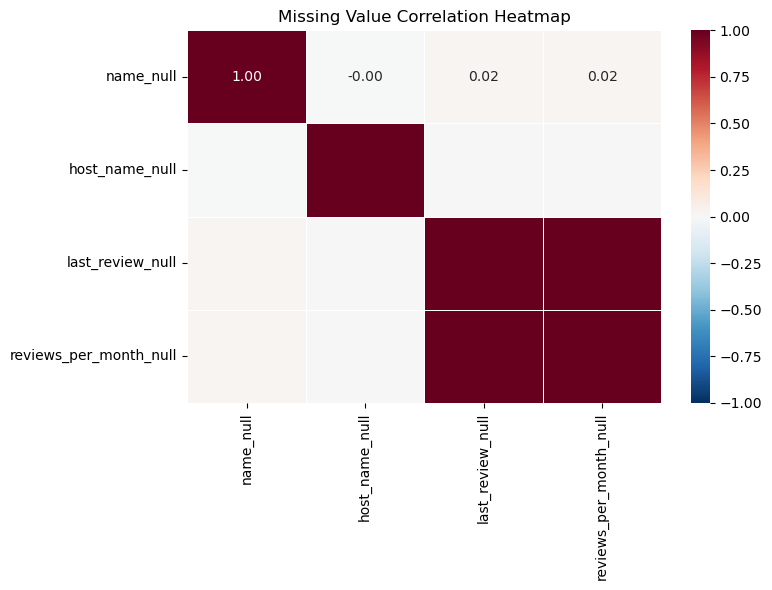


📌 Correlation: number_of_reviews = 0 vs last_review is null
   reviews=0 & last_review null: 10052
   reviews=0 & last_review exists: 0
   reviews>0 & last_review null: 0
   reviews>0 & last_review exists: 38843
   ✅ Consistent pattern: last_review null if and only if number_of_reviews = 0

MISSING VALUE CORRELATION CHECK COMPLETE


In [27]:
# ============================================================================
# 5.3.4) MISSING VALUE CORRELATION
# ============================================================================

print("=" * 80)
print("5.3.4) MISSING VALUE CORRELATION")
print("=" * 80)

# Create missing value indicator matrix
missing_df = df.select(
    col("id"),
    col("name").isNull().cast("int").alias("name_null"),
    col("host_name").isNull().cast("int").alias("host_name_null"),
    col("last_review").isNull().cast("int").alias("last_review_null"),
    col("reviews_per_month").isNull().cast("int").alias("reviews_per_month_null"),
    col("number_of_reviews"),
    col("price")
).toPandas()

# Compute correlation matrix on missing indicators
missing_cols = ["name_null", "host_name_null", "last_review_null", "reviews_per_month_null"]
corr_matrix = missing_df[missing_cols].corr()

# Plot heatmap
plt.figure(figsize=(8, 6))
sns.heatmap(corr_matrix, annot=True, fmt=".2f", cmap="RdBu_r", vmin=-1, vmax=1, linewidths=0.5)
plt.title("Missing Value Correlation Heatmap")
plt.tight_layout()
plt.show()

# Check specific correlation
print(f"\n📌 Correlation: number_of_reviews = 0 vs last_review is null")
zero_reviews_null_last = df.filter((col("number_of_reviews") == 0) & col("last_review").isNull()).count()
zero_reviews_has_last = df.filter((col("number_of_reviews") == 0) & col("last_review").isNotNull()).count()
has_reviews_null_last = df.filter((col("number_of_reviews") > 0) & col("last_review").isNull()).count()
has_reviews_has_last = df.filter((col("number_of_reviews") > 0) & col("last_review").isNotNull()).count()

print(f"   reviews=0 & last_review null: {zero_reviews_null_last}")
print(f"   reviews=0 & last_review exists: {zero_reviews_has_last}")
print(f"   reviews>0 & last_review null: {has_reviews_null_last}")
print(f"   reviews>0 & last_review exists: {has_reviews_has_last}")

if zero_reviews_has_last == 0 and has_reviews_null_last == 0:
    print(f"   ✅ Consistent pattern: last_review null if and only if number_of_reviews = 0")
else:
    print(f"   ⚠️  Inconsistency detected in the pattern")

print("\n" + "=" * 80)
print("MISSING VALUE CORRELATION CHECK COMPLETE")
print("=" * 80)

### 5.4) UNIQUENESS CHECKS

### 5.4.1) Duplicate Rows

In [28]:
# ============================================================================
# 5.4.1) DUPLICATE ROWS
# ============================================================================

print("=" * 80)
print("5.4.1) DUPLICATE ROWS")
print("=" * 80)

total_rows = df.count()
distinct_rows = df.distinct().count()
duplicate_row_count = total_rows - distinct_rows

print(f"\nTotal rows: {total_rows}")
print(f"Distinct rows: {distinct_rows}")
print(f"Duplicate rows: {duplicate_row_count}")

if duplicate_row_count > 0:
    print(f"   ⚠️  {duplicate_row_count} duplicate rows detected")
else:
    print(f"   ✅ No duplicate rows")

print("\n" + "=" * 80)
print("DUPLICATE ROWS CHECK COMPLETE")
print("=" * 80)

StatementMeta(, d9fedb96-84b6-4dce-adf5-c89b6d485b09, 31, Finished, Available, Finished, False)

5.4.1) DUPLICATE ROWS

Total rows: 48895
Distinct rows: 48895
Duplicate rows: 0
   ✅ No duplicate rows

DUPLICATE ROWS CHECK COMPLETE


### 5.4.2) Duplicate IDs

In [29]:
# ============================================================================
# 5.4.2) DUPLICATE IDs
# ============================================================================

print("=" * 80)
print("5.4.2) DUPLICATE IDs")
print("=" * 80)

# Check id column for duplicates
id_counts = df.groupBy("id").count().filter(col("count") > 1)
duplicate_id_count = id_counts.count()

print(f"\n📌 Column: id")
print(f"Total distinct ids: {df.select('id').distinct().count()}")
print(f"Duplicate ids: {duplicate_id_count}")

if duplicate_id_count > 0:
    print(f"   ⚠️  {duplicate_id_count} duplicate ids detected")
    duplicate_ids = id_counts.orderBy(col("count").desc()).limit(10).collect()
    print(f"   Top duplicate ids:")
    for row in duplicate_ids:
        print(f"   └─ id={row['id']}: {row['count']} occurrences")
else:
    print(f"   ✅ No duplicate ids")

print("\n" + "=" * 80)
print("DUPLICATE IDs CHECK COMPLETE")
print("=" * 80)

StatementMeta(, d9fedb96-84b6-4dce-adf5-c89b6d485b09, 32, Finished, Available, Finished, False)

5.4.2) DUPLICATE IDs

📌 Column: id
Total distinct ids: 48895
Duplicate ids: 0
   ✅ No duplicate ids

DUPLICATE IDs CHECK COMPLETE


### 5.4.3) Unique Value Counts

In [30]:
# ============================================================================
# 5.4.3) UNIQUE VALUE COUNTS
# ============================================================================

print("=" * 80)
print("5.4.3) UNIQUE VALUE COUNTS")
print("=" * 80)

# Define categorical columns to check
categorical_columns = ["neighbourhood_group", "neighbourhood", "room_type", "host_name"]

for cat_col in categorical_columns:
    distinct_count = df.select(cat_col).distinct().count()
    total = df.count()
    distinct_pct = (distinct_count / total) * 100
    
    print(f"\n📌 Column: {cat_col}")
    print(f"   Distinct values: {distinct_count}")
    print(f"   Distinct percentage: {distinct_pct:.2f}%")
    
    if distinct_count == 1:
        print(f"   ⚠️  Only 1 unique value - column may be useless")
    elif cat_col == "host_name" and distinct_pct > 20:
        print(f"   ℹ️  High cardinality as expected for names")
    elif distinct_pct > 50:
        print(f"   ℹ️  High cardinality - may be too granular for categorical")

print("\n" + "=" * 80)
print("UNIQUE VALUE COUNTS CHECK COMPLETE")
print("=" * 80)

StatementMeta(, d9fedb96-84b6-4dce-adf5-c89b6d485b09, 33, Finished, Available, Finished, False)

5.4.3) UNIQUE VALUE COUNTS

📌 Column: neighbourhood_group
   Distinct values: 5
   Distinct percentage: 0.01%

📌 Column: neighbourhood
   Distinct values: 221
   Distinct percentage: 0.45%

📌 Column: room_type
   Distinct values: 3
   Distinct percentage: 0.01%

📌 Column: host_name
   Distinct values: 11453
   Distinct percentage: 23.42%
   ℹ️  High cardinality as expected for names

UNIQUE VALUE COUNTS CHECK COMPLETE


##### Explanation

These numbers tell you how many unique values exist in each column relative to the total 48,895 rows:

- neighbourhood_group: 5 values across 48,895 rows = very low cardinality (0.01%). This is a good categorical column with few distinct categories - perfect for grouping and analysis.

- neighbourhood: 221 values = 0.45%. Low cardinality relative to total rows. Each neighborhood appears in many rows, making it useful for aggregation and grouping.

- room_type: 3 values = 0.01%. Extremely low cardinality. Like a boolean with 3 states - ideal for filtering and grouping.

- host_name: 11,453 values = 23.42%. Each host name appears roughly 4 times on average (48,895 / 11,453). This is moderate-high cardinality. It means many unique hosts with few listings each. For names this is expected - it's not a good categorical for grouping but fine for identification.

The pattern to watch for: if a column had exactly 48,895 distinct values (100%), it would be row-level unique and useless as a categorical. If it had 1 value (near 0%), it would have no discriminatory power. These columns all look healthy.

Low percentages indicate these are good categorical dimensions — few distinct values repeated many times across rows. The lower the percentage, the fewer categories you're working with.


### 5.5) CONSISTENCY CHECKS

### 5.5.1) Cross-Column Validation

In [31]:
# ============================================================================
# 5.5.1) CROSS-COLUMN VALIDATION
# ============================================================================

print("=" * 80)
print("5.5.1) CROSS-COLUMN VALIDATION")
print("=" * 80)

# Check: number_of_reviews = 0  =>  last_review IS NULL and reviews_per_month IS NULL
print(f"\n📌 Rule: number_of_reviews = 0 => last_review IS NULL AND reviews_per_month IS NULL")
violations = df.filter(
    (col("number_of_reviews") == 0) & 
    (col("last_review").isNotNull() | col("reviews_per_month").isNotNull())
).count()
print(f"   Violations: {violations}")
if violations > 0:
    print(f"   ⚠️  Rows with 0 reviews but have review dates or rates")
else:
    print(f"   ✅ Rule holds")

# Check: number_of_reviews > 0  =>  last_review IS NOT NULL and reviews_per_month IS NOT NULL
print(f"\n📌 Rule: number_of_reviews > 0 => last_review IS NOT NULL AND reviews_per_month IS NOT NULL")
violations = df.filter(
    (col("number_of_reviews") > 0) & 
    (col("last_review").isNull() | col("reviews_per_month").isNull())
).count()
print(f"   Violations: {violations}")
if violations > 0:
    print(f"   ⚠️  Rows with reviews but missing review dates or rates")
else:
    print(f"   ✅ Rule holds")

print("\n" + "=" * 80)
print("CROSS-COLUMN VALIDATION COMPLETE")
print("=" * 80)

StatementMeta(, d9fedb96-84b6-4dce-adf5-c89b6d485b09, 34, Finished, Available, Finished, False)

5.5.1) CROSS-COLUMN VALIDATION

📌 Rule: number_of_reviews = 0 => last_review IS NULL AND reviews_per_month IS NULL
   Violations: 0
   ✅ Rule holds

📌 Rule: number_of_reviews > 0 => last_review IS NOT NULL AND reviews_per_month IS NOT NULL
   Violations: 0
   ✅ Rule holds

CROSS-COLUMN VALIDATION COMPLETE


For this dataset, the only logical relationship that can be validated is:

- **number_of_reviews > 0 ↔ last_review IS NOT NULL**: Already confirmed in 5.3.3

### 5.5.2) Logical Contradictions

In [33]:
# ============================================================================
# 5.5.2) LOGICAL CONTRADICTIONS (EXPANDED)
# ============================================================================

from pyspark.sql.functions import count

print("=" * 80)
print("5.5.2) LOGICAL CONTRADICTIONS")
print("=" * 80)

# 1) availability_365 > 0 but minimum_nights > availability_365
print(f"\n📌 Rule 1: minimum_nights <= availability_365 (when availability > 0)")
violations = df.filter(
    (col("availability_365") > 0) & 
    (col("minimum_nights") > col("availability_365"))
)
print(f"   Violations: {violations.count()}")
if violations.count() > 0:
    violations.select("id", "minimum_nights", "availability_365").show(10, truncate=False)

# 2) price = 0 but availability_365 > 0
print(f"\n📌 Rule 2: price > 0 for available listings")
violations = df.filter(
    (col("availability_365") > 0) & 
    (col("price") == 0)
)
print(f"   Violations: {violations.count()}")
if violations.count() > 0:
    violations.select("id", "price", "availability_365").show(10, truncate=False)

# 3) calculated_host_listings_count < 1
print(f"\n📌 Rule 3: calculated_host_listings_count >= 1")
violations = df.filter(col("calculated_host_listings_count") < 1)
print(f"   Violations: {violations.count()}")
if violations.count() > 0:
    violations.select("id", "host_id", "calculated_host_listings_count").show(10, truncate=False)

# 4) price = 0 (free listing) but room_type is Entire home/apt
print(f"\n📌 Rule 4: price > 0 for Entire home/apt")
violations = df.filter(
    (col("price") == 0) & 
    (col("room_type") == "Entire home/apt")
)
print(f"   Violations: {violations.count()}")
if violations.count() > 0:
    violations.select("id", "price", "room_type").show(10, truncate=False)

# 5) availability_365 = 0 but minimum_nights > 0
print(f"\n📌 Rule 5: availability_365 = 0 => minimum_nights should be irrelevant (flag only)")
violations = df.filter(
    (col("availability_365") == 0) & 
    (col("minimum_nights") > 0)
)
print(f"   Rows with availability=0 and minimum_nights>0: {violations.count()}")
# This is common, not necessarily a violation - just flagging

# 6) number_of_reviews > 0 but last_review date is in the future
print(f"\n📌 Rule 6: last_review <= current date")
violations = df.filter(
    (col("number_of_reviews") > 0) & 
    (col("last_review") > current_date())
)
print(f"   Violations: {violations.count()}")
if violations.count() > 0:
    violations.select("id", "last_review", "number_of_reviews").show(10, truncate=False)

# 7) reviews_per_month > number_of_reviews
print(f"\n📌 Rule 7: reviews_per_month <= number_of_reviews")
violations = df.filter(
    (col("number_of_reviews") > 0) & 
    (col("reviews_per_month") > col("number_of_reviews"))
)
print(f"   Violations: {violations.count()}")
if violations.count() > 0:
    violations.select("id", "reviews_per_month", "number_of_reviews").show(10, truncate=False)

# 8) minimum_nights > 365
print(f"\n📌 Rule 8: minimum_nights <= 365")
violations = df.filter(col("minimum_nights") > 365)
print(f"   Violations: {violations.count()}")
if violations.count() > 0:
    violations.select("id", "minimum_nights").orderBy(col("minimum_nights").desc()).show(10, truncate=False)

# 9) latitude outside NYC bounds (~40.5 to ~40.9)
print(f"\n📌 Rule 9: latitude between 40.4 and 41.0 (NYC area)")
violations = df.filter(
    (col("latitude") < 40.4) | (col("latitude") > 41.0)
)
print(f"   Violations: {violations.count()}")
if violations.count() > 0:
    violations.select("id", "latitude", "longitude", "neighbourhood_group").show(10, truncate=False)

# 10) longitude outside NYC bounds (~-74.3 to ~-73.7)
print(f"\n📌 Rule 10: longitude between -74.3 and -73.5 (NYC area)")
violations = df.filter(
    (col("longitude") < -74.3) | (col("longitude") > -73.5)
)
print(f"   Violations: {violations.count()}")
if violations.count() > 0:
    violations.select("id", "latitude", "longitude", "neighbourhood_group").show(10, truncate=False)

# 11) calculated_host_listings_count = 0 but host has multiple listings
print(f"\n📌 Rule 11: calculated_host_listings_count matches actual listing count per host")
host_actual_counts = df.groupBy("host_id").agg(count("*").alias("actual_count"))
host_listed_counts = df.select("host_id", "calculated_host_listings_count").distinct()
host_check = host_actual_counts.join(host_listed_counts, "host_id")
violations = host_check.filter(col("actual_count") > col("calculated_host_listings_count"))
print(f"   Hosts with more actual listings than calculated: {violations.count()}")
if violations.count() > 0:
    violations.show(10, truncate=False)

# 12) availability_365 = 0 but price > 0
print(f"\n📌 Rule 12: availability_365 = 0 with price > 0 (unavailable but priced)")
violations = df.filter(
    (col("availability_365") == 0) & 
    (col("price") > 0)
)
print(f"   Violations: {violations.count()}")
if violations.count() > 0:
    violations.select("id", "price", "availability_365").show(10, truncate=False)

# 13) minimum_nights = 0
print(f"\n📌 Rule 13: minimum_nights >= 1")
violations = df.filter(col("minimum_nights") < 1)
print(f"   Violations: {violations.count()}")
if violations.count() > 0:
    violations.select("id", "minimum_nights").show(10, truncate=False)

# 14) number_of_reviews > 0 and reviews_per_month is null
print(f"\n📌 Rule 14: number_of_reviews > 0 => reviews_per_month IS NOT NULL")
violations = df.filter(
    (col("number_of_reviews") > 0) & 
    (col("reviews_per_month").isNull())
)
print(f"   Violations: {violations.count()}")
if violations.count() > 0:
    violations.select("id", "number_of_reviews", "reviews_per_month").show(10, truncate=False)

print("\n" + "=" * 80)
print("LOGICAL CONTRADICTIONS COMPLETE")
print("=" * 80)

StatementMeta(, d9fedb96-84b6-4dce-adf5-c89b6d485b09, 37, Finished, Available, Finished, False)

5.5.2) LOGICAL CONTRADICTIONS

📌 Rule 1: minimum_nights <= availability_365 (when availability > 0)
   Violations: 833
+------+--------------+----------------+
|id    |minimum_nights|availability_365|
+------+--------------+----------------+
|24285 |30            |9               |
|31555 |29            |12              |
|32363 |2             |1               |
|36133 |3             |1               |
|45940 |4             |1               |
|61509 |200           |140             |
|62095 |3             |2               |
|139624|20            |3               |
|211078|3             |1               |
|241159|6             |4               |
+------+--------------+----------------+
only showing top 10 rows


📌 Rule 2: price > 0 for available listings
   Violations: 8
+--------+-----+----------------+
|id      |price|availability_365|
+--------+-----+----------------+
|18750597|0    |28              |
|20333471|0    |127             |
|20624541|0    |73              |
|20639628|0    |

### Issue #12: `minimum_nights` Exceeds `availability_365`

833 listings require more minimum nights than the available days. A listing cannot fulfill a booking if the minimum stay exceeds availability.

**Examples:**
- id=24285: minimum_nights=30, availability=9 days
- id=61509: minimum_nights=200, availability=140 days
- id=139624: minimum_nights=20, availability=3 days

### Issue #13: Available Listings with `price = 0`

8 listings are available (availability_365 > 0) but have a price of $0.

**Examples:**
- id=18750597: price=0, availability=28 days
- id=20333471: price=0, availability=127 days
- id=20639914: price=0, availability=222 days

### Issue #14: Entire Home/Apt Listed for $0

2 entire home/apt listings have a price of $0, which is logically inconsistent for a full property rental.

**Examples:**
- id=20624541: Entire home/apt, price=0
- id=20933849: Entire home/apt, price=0

### Issue #15: Unavailable Listings Still Priced

17,530 listings have availability_365=0 (not available) but still have a price > 0. While not necessarily an error, this represents listings that are inactive but retain pricing data.

**Examples:**
- id=5022: price=$80, availability=0
- id=7801: price=$299, availability=0
- id=6090: price=$120, availability=0

### 5.5.3) Dependency Violations

In [34]:
# ============================================================================
# 5.5.3) DEPENDENCY VIOLATIONS
# ============================================================================

print("=" * 80)
print("5.5.3) DEPENDENCY VIOLATIONS")
print("=" * 80)

# Rule 1: host_id should map to a single host_name
print(f"\n📌 Rule 1: Each host_id maps to exactly one host_name")
host_consistency = df.groupBy("host_id").agg(countDistinct("host_name").alias("name_count"))
violations = host_consistency.filter(col("name_count") > 1)
print(f"   Violations: {violations.count()}")
if violations.count() > 0:
    print(f"   ⚠️  Host IDs with multiple different names")
    violations.show(10, truncate=False)
else:
    print(f"   ✅ Rule holds")

# Rule 2: neighbourhood should belong to its neighbourhood_group
# Check if any neighbourhood appears in multiple neighbourhood_groups
print(f"\n📌 Rule 2: Each neighbourhood belongs to exactly one neighbourhood_group")
neighbourhood_consistency = df.groupBy("neighbourhood").agg(countDistinct("neighbourhood_group").alias("group_count"))
violations = neighbourhood_consistency.filter(col("group_count") > 1)
print(f"   Violations: {violations.count()}")
if violations.count() > 0:
    print(f"   ⚠️  Neighbourhoods assigned to multiple boroughs")
    violations.show(10, truncate=False)
else:
    print(f"   ✅ Rule holds")

# Rule 3: number_of_reviews > 0 => last_review IS NOT NULL AND reviews_per_month IS NOT NULL
print(f"\n📌 Rule 3: number_of_reviews > 0 => last_review IS NOT NULL AND reviews_per_month IS NOT NULL")
violations = df.filter(
    (col("number_of_reviews") > 0) & 
    (col("last_review").isNull() | col("reviews_per_month").isNull())
)
print(f"   Violations: {violations.count()}")
if violations.count() > 0:
    print(f"   ⚠️  Listings with reviews but missing review data")
    violations.select("id", "number_of_reviews", "last_review", "reviews_per_month").show(10, truncate=False)
else:
    print(f"   ✅ Rule holds")

# Rule 4: number_of_reviews = 0 => last_review IS NULL AND reviews_per_month IS NULL
print(f"\n📌 Rule 4: number_of_reviews = 0 => last_review IS NULL AND reviews_per_month IS NULL")
violations = df.filter(
    (col("number_of_reviews") == 0) & 
    (col("last_review").isNotNull() | col("reviews_per_month").isNotNull())
)
print(f"   Violations: {violations.count()}")
if violations.count() > 0:
    print(f"   ⚠️  Listings with no reviews but have review data")
    violations.select("id", "number_of_reviews", "last_review", "reviews_per_month").show(10, truncate=False)
else:
    print(f"   ✅ Rule holds")

# Rule 5: reviews_per_month should not exceed number_of_reviews
print(f"\n📌 Rule 5: reviews_per_month <= number_of_reviews")
violations = df.filter(
    (col("reviews_per_month").isNotNull()) & 
    (col("reviews_per_month") > col("number_of_reviews"))
)
print(f"   Violations: {violations.count()}")
if violations.count() > 0:
    print(f"   ⚠️  Monthly reviews exceed total reviews")
    violations.select("id", "reviews_per_month", "number_of_reviews").show(10, truncate=False)
else:
    print(f"   ✅ Rule holds")

# Rule 6: Same host_id with multiple listings should have consistent host_name across all rows
print(f"\n📌 Rule 6: host_name is consistent across all rows for the same host_id")
host_name_violations = df.groupBy("host_id").agg(
    countDistinct("host_name").alias("name_variations")
).filter(col("name_variations") > 1)
print(f"   Violations: {host_name_violations.count()}")
if host_name_violations.count() > 0:
    print(f"   ⚠️  Inconsistent host names for same host_id")
    # Show examples
    inconsistent_hosts = host_name_violations.select("host_id").limit(5)
    df.join(inconsistent_hosts, "host_id") \
      .select("host_id", "host_name", "id") \
      .orderBy("host_id") \
      .show(20, truncate=False)
else:
    print(f"   ✅ Rule holds")

print("\n" + "=" * 80)
print("DEPENDENCY VIOLATIONS COMPLETE")
print("=" * 80)

StatementMeta(, d9fedb96-84b6-4dce-adf5-c89b6d485b09, 38, Finished, Available, Finished, False)

5.5.3) DEPENDENCY VIOLATIONS

📌 Rule 1: Each host_id maps to exactly one host_name
   Violations: 0
   ✅ Rule holds

📌 Rule 2: Each neighbourhood belongs to exactly one neighbourhood_group
   Violations: 0
   ✅ Rule holds

📌 Rule 3: number_of_reviews > 0 => last_review IS NOT NULL AND reviews_per_month IS NOT NULL
   Violations: 0
   ✅ Rule holds

📌 Rule 4: number_of_reviews = 0 => last_review IS NULL AND reviews_per_month IS NULL
   Violations: 0
   ✅ Rule holds

📌 Rule 5: reviews_per_month <= number_of_reviews
   Violations: 0
   ✅ Rule holds

📌 Rule 6: host_name is consistent across all rows for the same host_id
   Violations: 0
   ✅ Rule holds

DEPENDENCY VIOLATIONS COMPLETE


### 5.5.4) Value Range Logic

In [35]:
# ============================================================================
# 5.5.4) VALUE RANGE LOGIC
# ============================================================================

print("=" * 80)
print("5.5.4) VALUE RANGE LOGIC")
print("=" * 80)

# Rule 1: latitude and longitude should be consistent with neighbourhood_group
# Manhattan is roughly lat 40.70-40.88, lon -74.02 to -73.91
# Brooklyn is roughly lat 40.55-40.74, lon -74.04 to -73.83
# Queens is roughly lat 40.54-40.80, lon -74.04 to -73.70
# Bronx is roughly lat 40.78-40.92, lon -73.93 to -73.76
# Staten Island is roughly lat 40.48-40.65, lon -74.26 to -74.03

borough_bounds = {
    "Manhattan": {"lat_min": 40.68, "lat_max": 40.90, "lon_min": -74.03, "lon_max": -73.90},
    "Brooklyn": {"lat_min": 40.55, "lat_max": 40.74, "lon_min": -74.05, "lon_max": -73.83},
    "Queens": {"lat_min": 40.54, "lat_max": 40.80, "lon_min": -74.05, "lon_max": -73.70},
    "Bronx": {"lat_min": 40.78, "lat_max": 40.92, "lon_min": -73.94, "lon_max": -73.76},
    "Staten Island": {"lat_min": 40.48, "lat_max": 40.65, "lon_min": -74.26, "lon_max": -74.03}
}

print(f"\n📌 Rule 1: Coordinates match neighbourhood_group boundaries")
total_violations = 0
for borough, bounds in borough_bounds.items():
    violations = df.filter(
        (col("neighbourhood_group") == borough) &
        (
            (col("latitude") < bounds["lat_min"]) |
            (col("latitude") > bounds["lat_max"]) |
            (col("longitude") < bounds["lon_min"]) |
            (col("longitude") > bounds["lon_max"])
        )
    ).count()
    
    if violations > 0:
        print(f"   ⚠️  {borough}: {violations} listings outside expected coordinate bounds")
        total_violations += violations

if total_violations == 0:
    print(f"   ✅ All coordinates match their borough boundaries")
else:
    print(f"   Total violations: {total_violations}")

# Rule 2: number_of_reviews and reviews_per_month should align temporally
# reviews_per_month * months_active ≈ number_of_reviews
# If last_review exists, the listing has been active at least until that date
# Simple check: reviews_per_month * 12 should not grossly exceed number_of_reviews for new listings
print(f"\n📌 Rule 2: reviews_per_month * 12 <= number_of_reviews * 2 (sanity check)")
violations = df.filter(
    col("reviews_per_month").isNotNull() &
    col("number_of_reviews").isNotNull() &
    (col("reviews_per_month") * 12 > col("number_of_reviews") * 2) &
    (col("number_of_reviews") > 0)
)
print(f"   Violations: {violations.count()}")
if violations.count() > 0:
    print(f"   ⚠️  reviews_per_month seems too high relative to total reviews")
    violations.select("id", "reviews_per_month", "number_of_reviews", "last_review") \
        .orderBy(col("reviews_per_month").desc()).show(10, truncate=False)
else:
    print(f"   ✅ Rule holds")

# Rule 3: calculated_host_listings_count vs actual listings per host
# calculated should be >= actual number of rows for that host
print(f"\n📌 Rule 3: calculated_host_listings_count >= actual rows per host_id")
host_actual = df.groupBy("host_id").agg(count("*").alias("actual_listings"))
host_declared = df.select("host_id", "calculated_host_listings_count").distinct()
host_check = host_actual.join(host_declared, "host_id")
violations = host_check.filter(col("actual_listings") > col("calculated_host_listings_count"))
print(f"   Violations: {violations.count()}")
if violations.count() > 0:
    print(f"   ⚠️  Hosts with more actual listings than declared")
    violations.orderBy(col("actual_listings").desc()).show(10, truncate=False)
else:
    print(f"   ✅ Rule holds")

# Rule 4: availability_365 range logic
# If availability_365 = 365, listing is available all year, minimum_nights should be reasonable
print(f"\n📌 Rule 4: availability_365 = 365 but minimum_nights > 30 (full year available but long minimum)")
violations = df.filter(
    (col("availability_365") == 365) &
    (col("minimum_nights") > 30)
)
print(f"   Listings available all year with minimum_nights > 30: {violations.count()}")
if violations.count() > 0:
    violations.select("id", "minimum_nights", "availability_365", "room_type") \
        .orderBy(col("minimum_nights").desc()).show(10, truncate=False)

print("\n" + "=" * 80)
print("VALUE RANGE LOGIC COMPLETE")
print("=" * 80)

StatementMeta(, d9fedb96-84b6-4dce-adf5-c89b6d485b09, 39, Finished, Available, Finished, False)

5.5.4) VALUE RANGE LOGIC

📌 Rule 1: Coordinates match neighbourhood_group boundaries
   ✅ All coordinates match their borough boundaries

📌 Rule 2: reviews_per_month * 12 <= number_of_reviews * 2 (sanity check)
   Violations: 6412
   ⚠️  reviews_per_month seems too high relative to total reviews
+--------+-----------------+-----------------+-----------+
|id      |reviews_per_month|number_of_reviews|last_review|
+--------+-----------------+-----------------+-----------+
|32678719|58.5             |156              |2019-07-07 |
|32678720|27.95            |82               |2019-07-07 |
|30423106|20.94            |37               |2019-07-08 |
|32678721|14.62            |38               |2019-07-04 |
|34392081|14.0             |28               |2019-06-26 |
|35495582|14.0             |14               |2019-07-07 |
|35055076|13.42            |17               |2019-07-05 |
|34150120|13.33            |32               |2019-07-05 |
|32611321|13.13            |42               |2019-07-

### Issue #16: `reviews_per_month` Disproportionately High vs Total Reviews

6,412 listings have a reviews_per_month rate that seems too high relative to their total number_of_reviews. This could indicate recently active listings with a high review velocity, or data anomalies.

**Examples:**
- id=32678719: 58.5 reviews/month but only 156 total (suggests listing is ~2.7 months old)
- id=35495582: 14.0 reviews/month but only 14 total (suggests listing is 1 month old)
- id=35055076: 13.42 reviews/month but only 17 total

### 5.5.5) Category Mapping

In [36]:
# ============================================================================
# 5.5.5) CATEGORY MAPPING
# ============================================================================

print("=" * 80)
print("5.5.5) CATEGORY MAPPING")
print("=" * 80)

# Rule 1: neighbourhood should be consistent with neighbourhood_group
# Check if any neighbourhood name appears in an unexpected borough
print(f"\n📌 Rule 1: neighbourhood names consistent with neighbourhood_group")
# Get unique neighbourhood -> neighbourhood_group mappings
neighbourhood_mapping = df.select("neighbourhood", "neighbourhood_group").distinct()
violations = neighbourhood_mapping.groupBy("neighbourhood").agg(count("*").alias("borough_count")).filter(col("borough_count") > 1)
print(f"   Neighbourhoods mapped to multiple boroughs: {violations.count()}")
if violations.count() > 0:
    print(f"   ⚠️  Inconsistent neighbourhood-to-borough mappings")
    violations.show(10, truncate=False)
else:
    print(f"   ✅ All neighbourhoods map to exactly one borough")

# Rule 2: room_type distribution should be consistent within neighbourhood_groups
print(f"\n📌 Rule 2: room_type distribution by neighbourhood_group")
room_type_by_borough = df.groupBy("neighbourhood_group", "room_type").agg(count("*").alias("count"))
room_type_by_borough.orderBy("neighbourhood_group", "room_type").show(truncate=False)

# Rule 3: host_name consistency check - same name but different host_ids
print(f"\n📌 Rule 3: host_name mapped to multiple host_ids (potential duplicate hosts)")
host_name_mapping = df.select("host_name", "host_id").filter(col("host_name").isNotNull()).distinct()
name_with_multiple_ids = host_name_mapping.groupBy("host_name").agg(count("*").alias("id_count")).filter(col("id_count") > 1)
print(f"   Host names with multiple host_ids: {name_with_multiple_ids.count()}")
if name_with_multiple_ids.count() > 0:
    print(f"   ℹ️  Common names may map to different hosts (expected)")
    name_with_multiple_ids.orderBy(col("id_count").desc()).show(10, truncate=False)

print("\n" + "=" * 80)
print("CATEGORY MAPPING COMPLETE")
print("=" * 80)



StatementMeta(, d9fedb96-84b6-4dce-adf5-c89b6d485b09, 40, Finished, Available, Finished, False)

5.5.5) CATEGORY MAPPING

📌 Rule 1: neighbourhood names consistent with neighbourhood_group
   Neighbourhoods mapped to multiple boroughs: 0
   ✅ All neighbourhoods map to exactly one borough

📌 Rule 2: room_type distribution by neighbourhood_group
+-------------------+---------------+-----+
|neighbourhood_group|room_type      |count|
+-------------------+---------------+-----+
|Bronx              |Entire home/apt|379  |
|Bronx              |Private room   |652  |
|Bronx              |Shared room    |60   |
|Brooklyn           |Entire home/apt|9559 |
|Brooklyn           |Private room   |10132|
|Brooklyn           |Shared room    |413  |
|Manhattan          |Entire home/apt|13199|
|Manhattan          |Private room   |7982 |
|Manhattan          |Shared room    |480  |
|Queens             |Entire home/apt|2096 |
|Queens             |Private room   |3372 |
|Queens             |Shared room    |198  |
|Staten Island      |Entire home/apt|176  |
|Staten Island      |Private room   |188  |
|Sta

### 5.5.6) Foreign Key Consistency

In [37]:
# ============================================================================
# 5.5.6) FOREIGN KEY CONSISTENCY
# ============================================================================

print("=" * 80)
print("5.5.6) FOREIGN KEY CONSISTENCY")
print("=" * 80)

# Since we only have a single table (Bronze.AB_NYC_2019), there are no lookup tables to reference.
# However, we can treat certain columns as self-referencing lookups

# Check: host_id consistency - if host_id appears, host_name should not be null
print(f"\n📌 Rule 1: host_id present => host_name is not null")
violations = df.filter(
    col("host_id").isNotNull() & col("host_name").isNull()
)
print(f"   Violations: {violations.count()}")
if violations.count() > 0:
    print(f"   ⚠️  Host IDs without names")
    violations.select("id", "host_id", "host_name").show(10, truncate=False)
else:
    print(f"   ✅ Rule holds")

# Check: neighbourhood_group should reference valid boroughs (self-referencing lookup)
print(f"\n📌 Rule 2: All neighbourhood_group values are valid NYC boroughs")
valid_boroughs = ["Bronx", "Brooklyn", "Manhattan", "Queens", "Staten Island"]
violations = df.filter(
    col("neighbourhood_group").isNotNull() & ~col("neighbourhood_group").isin(valid_boroughs)
)
print(f"   Violations: {violations.count()}")
if violations.count() > 0:
    print(f"   ⚠️  Invalid borough names")
    violations.select("neighbourhood_group").distinct().show(truncate=False)
else:
    print(f"   ✅ Rule holds")

# Check: room_type should be one of the 3 valid types
print(f"\n📌 Rule 3: All room_type values are valid")
valid_room_types = ["Entire home/apt", "Private room", "Shared room"]
violations = df.filter(
    col("room_type").isNotNull() & ~col("room_type").isin(valid_room_types)
)
print(f"   Violations: {violations.count()}")
if violations.count() > 0:
    print(f"   ⚠️  Invalid room types")
    violations.select("room_type").distinct().show(truncate=False)
else:
    print(f"   ✅ Rule holds")

print("\n" + "=" * 80)
print("FOREIGN KEY CONSISTENCY COMPLETE")
print("=" * 80)

StatementMeta(, d9fedb96-84b6-4dce-adf5-c89b6d485b09, 41, Finished, Available, Finished, False)

5.5.6) FOREIGN KEY CONSISTENCY

📌 Rule 1: host_id present => host_name is not null
   Violations: 21
   ⚠️  Host IDs without names
+-------+--------+---------+
|id     |host_id |host_name|
+-------+--------+---------+
|100184 |526653  |NULL     |
|1449546|7779204 |NULL     |
|4183989|919218  |NULL     |
|4446862|23077718|NULL     |
|4763327|24576978|NULL     |
|6292866|32722063|NULL     |
|6360224|33134899|NULL     |
|6786181|32722063|NULL     |
|6992973|5162530 |NULL     |
|7556587|39608626|NULL     |
+-------+--------+---------+
only showing top 10 rows


📌 Rule 2: All neighbourhood_group values are valid NYC boroughs
   Violations: 0
   ✅ Rule holds

📌 Rule 3: All room_type values are valid
   Violations: 0
   ✅ Rule holds

FOREIGN KEY CONSISTENCY COMPLETE


### Issue #17: Host IDs Without Host Names

21 listings have a `host_id` but no `host_name`, breaking the expected relationship that every host should have a name.

**Examples:**
- id=100184: host_id=526653, host_name=NULL
- id=1449546: host_id=7779204, host_name=NULL
- id=4183989: host_id=919218, host_name=NULL

### 5.6) ACCURACY CHECKS

### 5.6.1) Outlier Detection

In [38]:
# ============================================================================
# 5.6) OUTLIER DETECTION
# ============================================================================
from pyspark.sql.functions import mean, stddev, abs as spark_abs, skewness, kurtosis

print("=" * 80)
print("5.6.1) OUTLIER DETECTION")
print("=" * 80)

# Define numeric columns for outlier detection
numeric_cols = ["price", "minimum_nights", "number_of_reviews", "reviews_per_month", 
                "calculated_host_listings_count", "availability_365"]

for num_col in numeric_cols:
    # Calculate stats
    stats = df.select(
        mean(col(num_col)).alias("mean"),
        stddev(col(num_col)).alias("stddev"),
        spark_min(col(num_col)).alias("min"),
        spark_max(col(num_col)).alias("max")
    ).collect()[0]
    
    mean_val = stats["mean"]
    stddev_val = stats["stddev"]
    min_val = stats["min"]
    max_val = stats["max"]
    
    # Outliers: values beyond 3 standard deviations from mean
    upper_bound = mean_val + (3 * stddev_val) if stddev_val else None
    lower_bound = mean_val - (3 * stddev_val) if stddev_val else None
    
    print(f"\n📌 Column: {num_col}")
    print(f"   Mean: {mean_val:.2f}")
    print(f"   StdDev: {stddev_val:.2f}")
    print(f"   Min: {min_val}")
    print(f"   Max: {max_val}")
    
    if upper_bound:
        outlier_count = df.filter(col(num_col) > upper_bound).count()
        outlier_pct = (outlier_count / total_rows) * 100
        print(f"   Upper bound (3σ): {upper_bound:.2f}")
        print(f"   Outliers above: {outlier_count} ({outlier_pct:.2f}%)")
        
        if outlier_count > 0 and outlier_pct < 5:
            print(f"   Top outliers:")
            df.select("id", col(num_col)) \
                .filter(col(num_col) > upper_bound) \
                .orderBy(col(num_col).desc()) \
                .show(5, truncate=False)

print("\n" + "=" * 80)
print("OUTLIER DETECTION COMPLETE")
print("=" * 80)


StatementMeta(, d9fedb96-84b6-4dce-adf5-c89b6d485b09, 42, Finished, Available, Finished, False)

5.6.1) OUTLIER DETECTION

📌 Column: price
   Mean: 152.72
   StdDev: 240.15
   Min: 0
   Max: 10000
   Upper bound (3σ): 873.18
   Outliers above: 388 (0.79%)
   Top outliers:
+--------+-----+
|id      |price|
+--------+-----+
|13894339|10000|
|7003697 |10000|
|22436899|10000|
|9528920 |9999 |
|4737930 |9999 |
+--------+-----+
only showing top 5 rows


📌 Column: minimum_nights
   Mean: 7.03
   StdDev: 20.51
   Min: 1
   Max: 1250
   Upper bound (3σ): 68.56
   Outliers above: 327 (0.67%)
   Top outliers:
+--------+--------------+
|id      |minimum_nights|
+--------+--------------+
|4204302 |1250          |
|1615764 |1000          |
|10053943|999           |
|20990053|999           |
|30378211|999           |
+--------+--------------+
only showing top 5 rows


📌 Column: number_of_reviews
   Mean: 23.27
   StdDev: 44.55
   Min: 0
   Max: 629
   Upper bound (3σ): 156.93
   Outliers above: 1221 (2.50%)
   Top outliers:
+--------+-----------------+
|id      |number_of_reviews|
+--------+----

### Issue #18: Price Outliers

388 listings (0.79%) have prices exceeding $873.18 (3 standard deviations above mean of $152.72).

**Examples:**
- id=13894339: $10,000
- id=7003697: $10,000
- id=22436899: $10,000

### Issue #19: Minimum Nights Outliers

327 listings (0.67%) require minimum stays exceeding 68 nights (3 standard deviations above mean of 7).

**Examples:**
- id=4204302: 1,250 nights
- id=1615764: 1,000 nights
- id=10053943: 999 nights

### Issue #20: Review Count Outliers

1,221 listings (2.50%) have review counts exceeding 157 (3 standard deviations above mean of 23).

**Examples:**
- id=9145202: 629 reviews
- id=903972: 607 reviews
- id=903947: 597 reviews

### Issue #21: Reviews Per Month Outliers

608 listings (1.24%) exceed 6.41 reviews per month (3 standard deviations above mean of 1.37).

**Examples:**
- id=32678719: 58.5 reviews/month
- id=32678720: 27.95 reviews/month
- id=30423106: 20.94 reviews/month

### Issue #22: Host Listing Count Outliers

680 hosts (1.39%) have more than 106 listings (3 standard deviations above mean of 7), indicating potential commercial operators.

**Examples:**
- host listings: 327 (multiple hosts at this maximum)

### 5.6.2) Statistical Anomalies

In [39]:
# ============================================================================
# 5.6.2) STATISTICAL ANOMALIES
# ============================================================================

print("=" * 80)
print("5.6.2) STATISTICAL ANOMALIES")
print("=" * 80)

# Check skewness and kurtosis for key columns
for num_col in ["price", "minimum_nights", "number_of_reviews"]:
    stats = df.select(
        skewness(col(num_col)).alias("skew"),
        kurtosis(col(num_col)).alias("kurt")
    ).collect()[0]
    
    print(f"\n📌 Column: {num_col}")
    print(f"   Skewness: {stats['skew']:.2f}")
    print(f"   Kurtosis: {stats['kurt']:.2f}")
    
    if abs(stats['skew']) > 2:
        print(f"   ⚠️  Highly skewed distribution (|skew| > 2)")
    if stats['kurt'] > 7:
        print(f"   ⚠️  Heavy tails / extreme outliers (kurtosis > 7)")

# Distribution check: price distribution by room_type
print(f"\n📌 Price distribution by room_type:")
df.groupBy("room_type").agg(
    mean("price").alias("avg_price"),
    spark_min("price").alias("min_price"),
    spark_max("price").alias("max_price"),
    stddev("price").alias("stddev_price"),
    count("*").alias("count")
).orderBy("avg_price", ascending=False).show(truncate=False)

print("\n" + "=" * 80)
print("STATISTICAL ANOMALIES COMPLETE")
print("=" * 80)

StatementMeta(, d9fedb96-84b6-4dce-adf5-c89b6d485b09, 43, Finished, Available, Finished, False)

5.6.2) STATISTICAL ANOMALIES

📌 Column: price
   Skewness: 19.12
   Kurtosis: 585.61
   ⚠️  Highly skewed distribution (|skew| > 2)
   ⚠️  Heavy tails / extreme outliers (kurtosis > 7)

📌 Column: minimum_nights
   Skewness: 21.83
   Kurtosis: 853.98
   ⚠️  Highly skewed distribution (|skew| > 2)
   ⚠️  Heavy tails / extreme outliers (kurtosis > 7)

📌 Column: number_of_reviews
   Skewness: 3.69
   Kurtosis: 19.53
   ⚠️  Highly skewed distribution (|skew| > 2)
   ⚠️  Heavy tails / extreme outliers (kurtosis > 7)

📌 Price distribution by room_type:
+---------------+------------------+---------+---------+------------------+-----+
|room_type      |avg_price         |min_price|max_price|stddev_price      |count|
+---------------+------------------+---------+---------+------------------+-----+
|Entire home/apt|211.79424613325986|0        |10000    |284.0416109325119 |25409|
|Private room   |89.78097285675894 |0        |10000    |160.20526236647572|22326|
|Shared room    |70.12758620689655 |0 

### Issue #23: Severely Skewed Distributions in Key Metrics

All three key numeric columns show extreme positive skew and heavy tails, indicating most values cluster at the low end with a small number of extreme outliers.

- **price**: skewness=19.12, kurtosis=585.61 — heavily dominated by lower-priced listings with rare luxury outliers
- **minimum_nights**: skewness=21.83, kurtosis=853.98 — most listings have short minimum stays, few require months/years
- **number_of_reviews**: skewness=3.69, kurtosis=19.53 — most listings have few reviews, few are highly popular

Price follows expected pattern by room type: Entire home/apt averages $211.79 vs Private room at $89.78 vs Shared room at $70.13.

### 5.6.3) Business Rule Violations


In [40]:

# ============================================================================
# 5.6.3) BUSINESS RULE VIOLATIONS
# ============================================================================

print("=" * 80)
print("5.6.3) BUSINESS RULE VIOLATIONS")
print("=" * 80)

# Rule 1: Price should be reasonable for room type
print(f"\n📌 Rule 1: Entire home/apt price > Private room price (on average)")
avg_by_type = df.groupBy("room_type").agg(mean("price").alias("avg_price")).orderBy("avg_price", ascending=False)
avg_by_type.show(truncate=False)

# Rule 2: Availability should not exceed days in a year
print(f"\n📌 Rule 2: availability_365 <= 365")
violations = df.filter(col("availability_365") > 365)
print(f"   Violations: {violations.count()}")
if violations.count() > 0:
    print(f"   ⚠️  Availability exceeds 365 days")
    violations.select("id", "availability_365").show(5, truncate=False)
else:
    print(f"   ✅ Rule holds")

# Rule 3: number_of_reviews should be >= 0
print(f"\n📌 Rule 3: number_of_reviews >= 0")
violations = df.filter(col("number_of_reviews") < 0)
print(f"   Violations: {violations.count()}")
if violations.count() > 0:
    print(f"   ⚠️  Negative review counts")
else:
    print(f"   ✅ Rule holds")

# Rule 4: price should be >= 0
print(f"\n📌 Rule 4: price >= 0")
violations = df.filter(col("price") < 0)
print(f"   Violations: {violations.count()}")
if violations.count() > 0:
    print(f"   ⚠️  Negative prices")
else:
    print(f"   ✅ Rule holds")

print("\n" + "=" * 80)
print("BUSINESS RULE VIOLATIONS COMPLETE")
print("=" * 80)

StatementMeta(, d9fedb96-84b6-4dce-adf5-c89b6d485b09, 44, Finished, Available, Finished, False)

5.6.3) BUSINESS RULE VIOLATIONS

📌 Rule 1: Entire home/apt price > Private room price (on average)
+---------------+------------------+
|room_type      |avg_price         |
+---------------+------------------+
|Entire home/apt|211.79424613325986|
|Private room   |89.78097285675894 |
|Shared room    |70.12758620689655 |
+---------------+------------------+


📌 Rule 2: availability_365 <= 365
   Violations: 0
   ✅ Rule holds

📌 Rule 3: number_of_reviews >= 0
   Violations: 0
   ✅ Rule holds

📌 Rule 4: price >= 0
   Violations: 0
   ✅ Rule holds

BUSINESS RULE VIOLATIONS COMPLETE


### 5.6.4) Impossible Values


In [41]:

# ============================================================================
# 5.6.4) IMPOSSIBLE VALUES
# ============================================================================

print("=" * 80)
print("5.6.4) IMPOSSIBLE VALUES")
print("=" * 80)

# Rule 1: Negative values in numeric columns
print(f"\n📌 Rule 1: No negative values in count/quantity columns")
negative_checks = ["price", "minimum_nights", "number_of_reviews", "calculated_host_listings_count", "availability_365"]
for c in negative_checks:
    neg_count = df.filter(col(c) < 0).count()
    if neg_count > 0:
        print(f"   ⚠️  {c}: {neg_count} negative values")
    else:
        print(f"   ✅ {c}: No negative values")

# Rule 2: Future dates
print(f"\n📌 Rule 2: last_review is not in the future")
future_dates = df.filter(
    col("last_review").isNotNull() & (col("last_review") > current_date())
).count()
print(f"   Future dates: {future_dates}")
if future_dates > 0:
    print(f"   ⚠️  Future review dates detected")
else:
    print(f"   ✅ Rule holds")

# Rule 3: Impossible coordinates (0,0)
print(f"\n📌 Rule 3: latitude and longitude are not (0,0)")
zero_coords = df.filter((col("latitude") == 0) & (col("longitude") == 0)).count()
print(f"   (0,0) coordinates: {zero_coords}")
if zero_coords > 0:
    print(f"   ⚠️  Impossible coordinates detected")
else:
    print(f"   ✅ Rule holds")

# Rule 4: reviews_per_month should not be negative
print(f"\n📌 Rule 4: reviews_per_month >= 0")
neg_reviews = df.filter(col("reviews_per_month").isNotNull() & (col("reviews_per_month") < 0)).count()
print(f"   Negative values: {neg_reviews}")
if neg_reviews > 0:
    print(f"   ⚠️  Negative reviews per month")
else:
    print(f"   ✅ Rule holds")

# Rule 5: calculated_host_listings_count should be integer > 0
print(f"\n📌 Rule 5: calculated_host_listings_count > 0")
zero_host = df.filter(col("calculated_host_listings_count") <= 0).count()
print(f"   Zero or negative: {zero_host}")
if zero_host > 0:
    print(f"   ⚠️  Invalid host listing counts")
else:
    print(f"   ✅ Rule holds")

print("\n" + "=" * 80)
print("IMPOSSIBLE VALUES COMPLETE")
print("=" * 80)

StatementMeta(, d9fedb96-84b6-4dce-adf5-c89b6d485b09, 45, Finished, Available, Finished, False)

5.6.4) IMPOSSIBLE VALUES

📌 Rule 1: No negative values in count/quantity columns
   ✅ price: No negative values
   ✅ minimum_nights: No negative values
   ✅ number_of_reviews: No negative values
   ✅ calculated_host_listings_count: No negative values
   ✅ availability_365: No negative values

📌 Rule 2: last_review is not in the future
   Future dates: 0
   ✅ Rule holds

📌 Rule 3: latitude and longitude are not (0,0)
   (0,0) coordinates: 0
   ✅ Rule holds

📌 Rule 4: reviews_per_month >= 0
   Negative values: 0
   ✅ Rule holds

📌 Rule 5: calculated_host_listings_count > 0
   Zero or negative: 0
   ✅ Rule holds

IMPOSSIBLE VALUES COMPLETE


### 5.7) DOMAIN VALIDATION


### 5.7.1) Geographic Validation

In [42]:
# ============================================================================
# 5.7.1) GEOGRAPHIC VALIDATION
# ============================================================================

print("=" * 80)
print("5.7.1) GEOGRAPHIC VALIDATION")
print("=" * 80)

# Valid NYC boroughs
valid_boroughs = ["Bronx", "Brooklyn", "Manhattan", "Queens", "Staten Island"]

print(f"\n📌 Rule 1: neighbourhood_group in valid NYC boroughs")
violations = df.filter(
    col("neighbourhood_group").isNotNull() & ~col("neighbourhood_group").isin(valid_boroughs)
)
print(f"   Violations: {violations.count()}")
if violations.count() > 0:
    print(f"   ⚠️  Invalid borough names")
    violations.select("neighbourhood_group").distinct().show(truncate=False)
else:
    print(f"   ✅ Rule holds")

# NYC coordinate bounds
print(f"\n📌 Rule 2: Coordinates within NYC boundaries (lat: 40.4-41.0, lon: -74.3 to -73.5)")
nyc_bounds = df.filter(
    col("latitude").isNotNull() & col("longitude").isNotNull() &
    (
        (col("latitude") < 40.4) | (col("latitude") > 41.0) |
        (col("longitude") < -74.3) | (col("longitude") > -73.5)
    )
)
print(f"   Outside NYC bounds: {nyc_bounds.count()}")
if nyc_bounds.count() > 0:
    print(f"   ⚠️  Coordinates outside NYC")
    nyc_bounds.select("id", "latitude", "longitude", "neighbourhood_group").show(10, truncate=False)
else:
    print(f"   ✅ Rule holds")

print("\n" + "=" * 80)
print("GEOGRAPHIC VALIDATION COMPLETE")
print("=" * 80)

StatementMeta(, d9fedb96-84b6-4dce-adf5-c89b6d485b09, 46, Finished, Available, Finished, False)

5.7.1) GEOGRAPHIC VALIDATION

📌 Rule 1: neighbourhood_group in valid NYC boroughs
   Violations: 0
   ✅ Rule holds

📌 Rule 2: Coordinates within NYC boundaries (lat: 40.4-41.0, lon: -74.3 to -73.5)
   Outside NYC bounds: 0
   ✅ Rule holds

GEOGRAPHIC VALIDATION COMPLETE


### 5.7.2) Department Validation: Room Type Column

In [43]:
# ============================================================================
# 5.7.2) ROOM TYPE VALIDATION
# ============================================================================

print("=" * 80)
print("5.7.2) ROOM TYPE VALIDATION")
print("=" * 80)

valid_room_types = ["Entire home/apt", "Private room", "Shared room"]

print(f"\n📌 Rule 1: room_type in valid Airbnb room types")
violations = df.filter(
    col("room_type").isNotNull() & ~col("room_type").isin(valid_room_types)
)
print(f"   Violations: {violations.count()}")
if violations.count() > 0:
    print(f"   ⚠️  Invalid room types")
    violations.select("room_type").distinct().show(truncate=False)
else:
    print(f"   ✅ Rule holds")

print("\n" + "=" * 80)
print("ROOM TYPE VALIDATION COMPLETE")
print("=" * 80)


StatementMeta(, d9fedb96-84b6-4dce-adf5-c89b6d485b09, 47, Finished, Available, Finished, False)

5.7.2) ROOM TYPE VALIDATION

📌 Rule 1: room_type in valid Airbnb room types
   Violations: 0
   ✅ Rule holds

ROOM TYPE VALIDATION COMPLETE


### 5.7.3) Salary Band Validation


In [44]:
# ============================================================================
# 5.7.3) PRICE BAND VALIDATION
# ============================================================================

print("=" * 80)
print("5.7.3) PRICE BAND VALIDATION")
print("=" * 80)

# Expected price ranges by room type
price_bands = {
    "Entire home/apt": (20, 2000),
    "Private room": (15, 1000),
    "Shared room": (10, 500)
}

print(f"\n📌 Rule 1: Prices within expected bands by room type")
total_violations = 0
for room_type, (min_price, max_price) in price_bands.items():
    violations = df.filter(
        (col("room_type") == room_type) &
        ((col("price") < min_price) | (col("price") > max_price))
    ).count()
    
    print(f"   {room_type}: {violations} outside ${min_price}-${max_price}")
    total_violations += violations

print(f"   Total outside expected bands: {total_violations}")

if total_violations > 0:
    print(f"   ⚠️  Prices outside expected bands for room type")
    # Show examples
    for room_type, (min_price, max_price) in price_bands.items():
        band_violations = df.filter(
            (col("room_type") == room_type) &
            ((col("price") < min_price) | (col("price") > max_price))
        )
        if band_violations.count() > 0:
            print(f"\n   {room_type} violations:")
            band_violations.select("id", "price", "room_type") \
                .orderBy(col("price").desc()) \
                .show(5, truncate=False)

print("\n" + "=" * 80)
print("PRICE BAND VALIDATION COMPLETE")
print("=" * 80)

StatementMeta(, d9fedb96-84b6-4dce-adf5-c89b6d485b09, 48, Finished, Available, Finished, False)

5.7.3) PRICE BAND VALIDATION

📌 Rule 1: Prices within expected bands by room type
   Entire home/apt: 89 outside $20-$2000
   Private room: 62 outside $15-$1000
   Shared room: 10 outside $10-$500
   Total outside expected bands: 161
   ⚠️  Prices outside expected bands for room type

   Entire home/apt violations:
+--------+-----+---------------+
|id      |price|room_type      |
+--------+-----+---------------+
|22436899|10000|Entire home/apt|
|13894339|10000|Entire home/apt|
|4737930 |9999 |Entire home/apt|
|31340283|9999 |Entire home/apt|
|23377410|8500 |Entire home/apt|
+--------+-----+---------------+
only showing top 5 rows


   Private room violations:
+--------+-----+------------+
|id      |price|room_type   |
+--------+-----+------------+
|7003697 |10000|Private room|
|9528920 |9999 |Private room|
|34895693|7500 |Private room|
|29547314|6500 |Private room|
|2919330 |5000 |Private room|
+--------+-----+------------+
only showing top 5 rows


   Shared room violations:
+--------

### 5.7.4) Date Range Validation


In [45]:

# ============================================================================
# 5.7.4) DATE RANGE VALIDATION
# ============================================================================

print("=" * 80)
print("5.7.4) DATE RANGE VALIDATION")
print("=" * 80)

# Airbnb was founded in 2008, NYC data from 2019, so last_review should be between 2008 and 2019
print(f"\n📌 Rule 1: last_review between 2008-01-01 and 2019-12-31")
violations = df.filter(
    col("last_review").isNotNull() &
    ((col("last_review") < "2008-01-01") | (col("last_review") > "2019-12-31"))
)
print(f"   Violations: {violations.count()}")
if violations.count() > 0:
    print(f"   ⚠️  Review dates outside expected range")
    violations.select("id", "last_review").orderBy("last_review").show(10, truncate=False)
else:
    print(f"   ✅ Rule holds")

# Check last_review not before 2011 (earliest reasonable for 2019 dataset)
print(f"\n📌 Rule 2: last_review should not be before 2011 (for 2019 dataset)")
violations = df.filter(
    col("last_review").isNotNull() & (col("last_review") < "2011-01-01")
)
print(f"   Reviews before 2011: {violations.count()}")
if violations.count() > 0:
    print(f"   ⚠️  Very old review dates")
    violations.select("id", "last_review", "number_of_reviews").orderBy("last_review").show(10, truncate=False)
else:
    print(f"   ✅ Rule holds")

print("\n" + "=" * 80)
print("DATE RANGE VALIDATION COMPLETE")
print("=" * 80)

StatementMeta(, d9fedb96-84b6-4dce-adf5-c89b6d485b09, 49, Finished, Available, Finished, False)

5.7.4) DATE RANGE VALIDATION

📌 Rule 1: last_review between 2008-01-01 and 2019-12-31
   Violations: 0
   ✅ Rule holds

📌 Rule 2: last_review should not be before 2011 (for 2019 dataset)
   Reviews before 2011: 0
   ✅ Rule holds

DATE RANGE VALIDATION COMPLETE


### 5.8) REFERENTIAL INTEGRITY CHECKS


In [46]:
# ============================================================================
# 5.8) REFERENTIAL INTEGRITY CHECKS
# ============================================================================

print("=" * 80)
print("5.8) REFERENTIAL INTEGRITY CHECKS")
print("=" * 80)

print("\n⚠️  NOT APPLICABLE: Referential integrity checks require multiple tables with foreign key relationships.")
print("   This dataset is a single table (Bronze.AB_NYC_2019) with no parent/child table relationships to validate.")
print("   No orphan records, invalid foreign keys, or missing parent records can be checked.")

print("\n" + "=" * 80)
print("REFERENTIAL INTEGRITY CHECKS COMPLETE")
print("=" * 80)

StatementMeta(, d9fedb96-84b6-4dce-adf5-c89b6d485b09, 50, Finished, Available, Finished, False)

5.8) REFERENTIAL INTEGRITY CHECKS

⚠️  NOT APPLICABLE: Referential integrity checks require multiple tables with foreign key relationships.
   This dataset is a single table (Bronze.AB_NYC_2019) with no parent/child table relationships to validate.
   No orphan records, invalid foreign keys, or missing parent records can be checked.

REFERENTIAL INTEGRITY CHECKS COMPLETE


### 5.9) TIMELINESS CHECKS


In [50]:
# ============================================================================
# 5.9) TIMELINESS CHECKS
# ============================================================================

print("=" * 80)
print("5.9) TIMELINESS CHECKS")
print("=" * 80)

# 5.9.1) DATA FRESHNESS
print(f"\n📌 5.9.1) Data Freshness")
print(f"   Most recent last_review date:")
most_recent = df.select(spark_max("last_review")).collect()[0][0]
oldest_review = df.select(spark_min("last_review")).collect()[0][0]
print(f"   Oldest review: {oldest_review}")
print(f"   Most recent review: {most_recent}")

if most_recent:
    from datetime import datetime
    current = datetime.now().date()
    days_since_last = (current - most_recent).days
    print(f"   Days since most recent review: {days_since_last}")
    if days_since_last > 365:
        print(f"   ⚠️  Data may be stale - most recent review over a year old")

# 5.9.2) LOAD TIMESTAMP ANALYSIS
print(f"\n📌 5.9.2) Load Timestamp Analysis")
print(f"   ⚠️  NOT APPLICABLE: No load timestamp column exists in the dataset.")
print(f"   Consider adding an ingestion_timestamp column in the Bronze layer for future monitoring.")

# 5.9.3) SOURCE-TO-TARGET LATENCY
print(f"\n📌 5.9.3) Source-to-Target Latency")
print(f"   ⚠️  NOT APPLICABLE: No source timestamp or load timestamp columns to compare.")

# 5.9.4) TEMPORAL CONSISTENCY
print(f"\n📌 5.9.4) Temporal Consistency")

# Check for future dates
future_reviews = df.filter(
    col("last_review").isNotNull() & (col("last_review") > current_date())
).count()
print(f"   Future review dates: {future_reviews}")

# Check for review dates older than Airbnb founding (2008)
very_old_reviews = df.filter(
    col("last_review").isNotNull() & (col("last_review") < "2008-01-01")
).count()
print(f"   Reviews before Airbnb founding (2008): {very_old_reviews}")

# Check review date distribution by year
print(f"\n   Review date distribution by year:")
df.filter(col("last_review").isNotNull()) \
    .select(year("last_review").alias("year")) \
    .groupBy("year") \
    .count() \
    .orderBy("year") \
    .show(truncate=False)

# 5.9.5) TEMPORAL GAPS
print(f"\n📌 5.9.5) Temporal Gaps")

# Check for gaps in last_review dates
print(f"   Checking for gaps in monthly review activity...")
monthly_reviews = df.filter(col("last_review").isNotNull()) \
    .select(date_format("last_review", "yyyy-MM").alias("month")) \
    .groupBy("month") \
    .count() \
    .orderBy("month")

monthly_data = monthly_reviews.collect()
if len(monthly_data) > 1:
    print(f"   Date range: {monthly_data[0]['month']} to {monthly_data[-1]['month']}")
    print(f"   Total months with reviews: {len(monthly_data)}")
    
    # Check if all expected months are present
    from datetime import datetime
    from dateutil.relativedelta import relativedelta
    import calendar
    
    first_month = datetime.strptime(monthly_data[0]['month'], "%Y-%m")
    last_month = datetime.strptime(monthly_data[-1]['month'], "%Y-%m")
    
    expected_months = set()
    current_month = first_month
    while current_month <= last_month:
        expected_months.add(current_month.strftime("%Y-%m"))
        current_month += relativedelta(months=1)
    
    actual_months = set(row['month'] for row in monthly_data)
    missing_months = sorted(expected_months - actual_months)
    
    if missing_months:
        print(f"   ⚠️  Missing months: {len(missing_months)}")
        print(f"   First 10 missing: {missing_months[:10]}")
        if len(missing_months) > 10:
            print(f"   ... and {len(missing_months) - 10} more")
    else:
        print(f"   ✅ No gaps - all months present in range")
else:
    print(f"   ℹ️  Insufficient data for gap analysis")

print("\n" + "=" * 80)
print("TIMELINESS CHECKS COMPLETE")
print("=" * 80)

StatementMeta(, d9fedb96-84b6-4dce-adf5-c89b6d485b09, 54, Finished, Available, Finished, False)

5.9) TIMELINESS CHECKS

📌 5.9.1) Data Freshness
   Most recent last_review date:
   Oldest review: 2011-03-28
   Most recent review: 2019-07-08
   Days since most recent review: 2585
   ⚠️  Data may be stale - most recent review over a year old

📌 5.9.2) Load Timestamp Analysis
   ⚠️  NOT APPLICABLE: No load timestamp column exists in the dataset.
   Consider adding an ingestion_timestamp column in the Bronze layer for future monitoring.

📌 5.9.3) Source-to-Target Latency
   ⚠️  NOT APPLICABLE: No source timestamp or load timestamp columns to compare.

📌 5.9.4) Temporal Consistency
   Future review dates: 0
   Reviews before Airbnb founding (2008): 0

   Review date distribution by year:
+----+-----+
|year|count|
+----+-----+
|2011|7    |
|2012|25   |
|2013|48   |
|2014|199  |
|2015|1393 |
|2016|2707 |
|2017|3205 |
|2018|6050 |
|2019|25209|
+----+-----+


📌 5.9.5) Temporal Gaps
   Checking for gaps in monthly review activity...
   Date range: 2011-03 to 2019-07
   Total months with rev

### Issue #24: Missing Load Timestamp Column

No ingestion or load timestamp column exists in the dataset, making it impossible to track data freshness, source-to-target latency, or load consistency. Recommend adding `ingestion_timestamp` in the Bronze layer.

### Issue #25: Temporal Gaps in Review Activity

9 months are missing from the review timeline between 2011-03 and 2019-07, all in the early years when review volume was very low.

**Missing months:** 2011-06, 2011-07, 2011-08, 2011-10, 2011-11, 2012-02, 2012-03, 2012-04, 2013-02

# 6) Univariate Analysis

StatementMeta(, d9fedb96-84b6-4dce-adf5-c89b6d485b09, 56, Finished, Available, Finished, False)

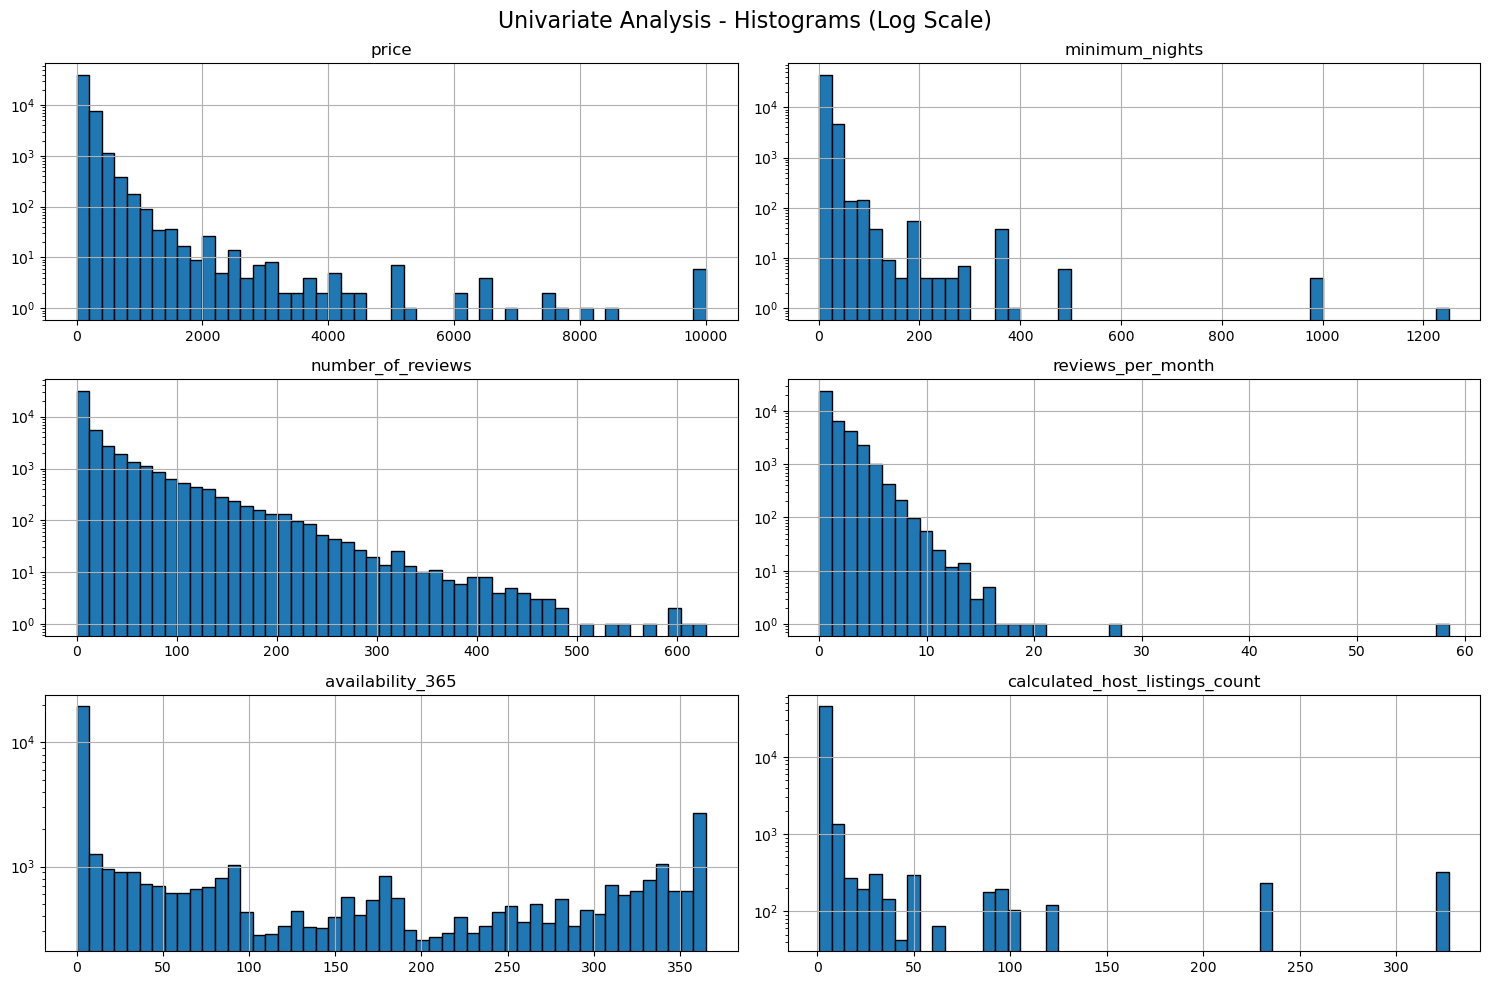

In [51]:
# Convert to pandas for visualization - all rows
pdf = df.select(["price", "minimum_nights", "number_of_reviews", "reviews_per_month", 
                 "availability_365", "calculated_host_listings_count"]).toPandas()

# ============================================================================
# UNIVARIATE - Histograms for all numeric columns
# ============================================================================
pdf.hist(bins=50, figsize=(15, 10), edgecolor='black', log=True)
plt.suptitle("Univariate Analysis - Histograms (Log Scale)", fontsize=16)
plt.tight_layout()
plt.show()

# Bivariate Analysis

StatementMeta(, d9fedb96-84b6-4dce-adf5-c89b6d485b09, 59, Finished, Available, Finished, False)

/home/trusted-service-user/cluster-env/trident_env/lib/python3.11/site-packages/seaborn/_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):
/home/trusted-service-user/cluster-env/trident_env/lib/python3.11/site-packages/seaborn/_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):
/home/trusted-service-user/cluster-env/trident_env/lib/python3.11/site-packages/seaborn/_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):
/home/trusted-service-user/cluster-env/trident_env/lib/python3.11/site-packages/seaborn/_ol

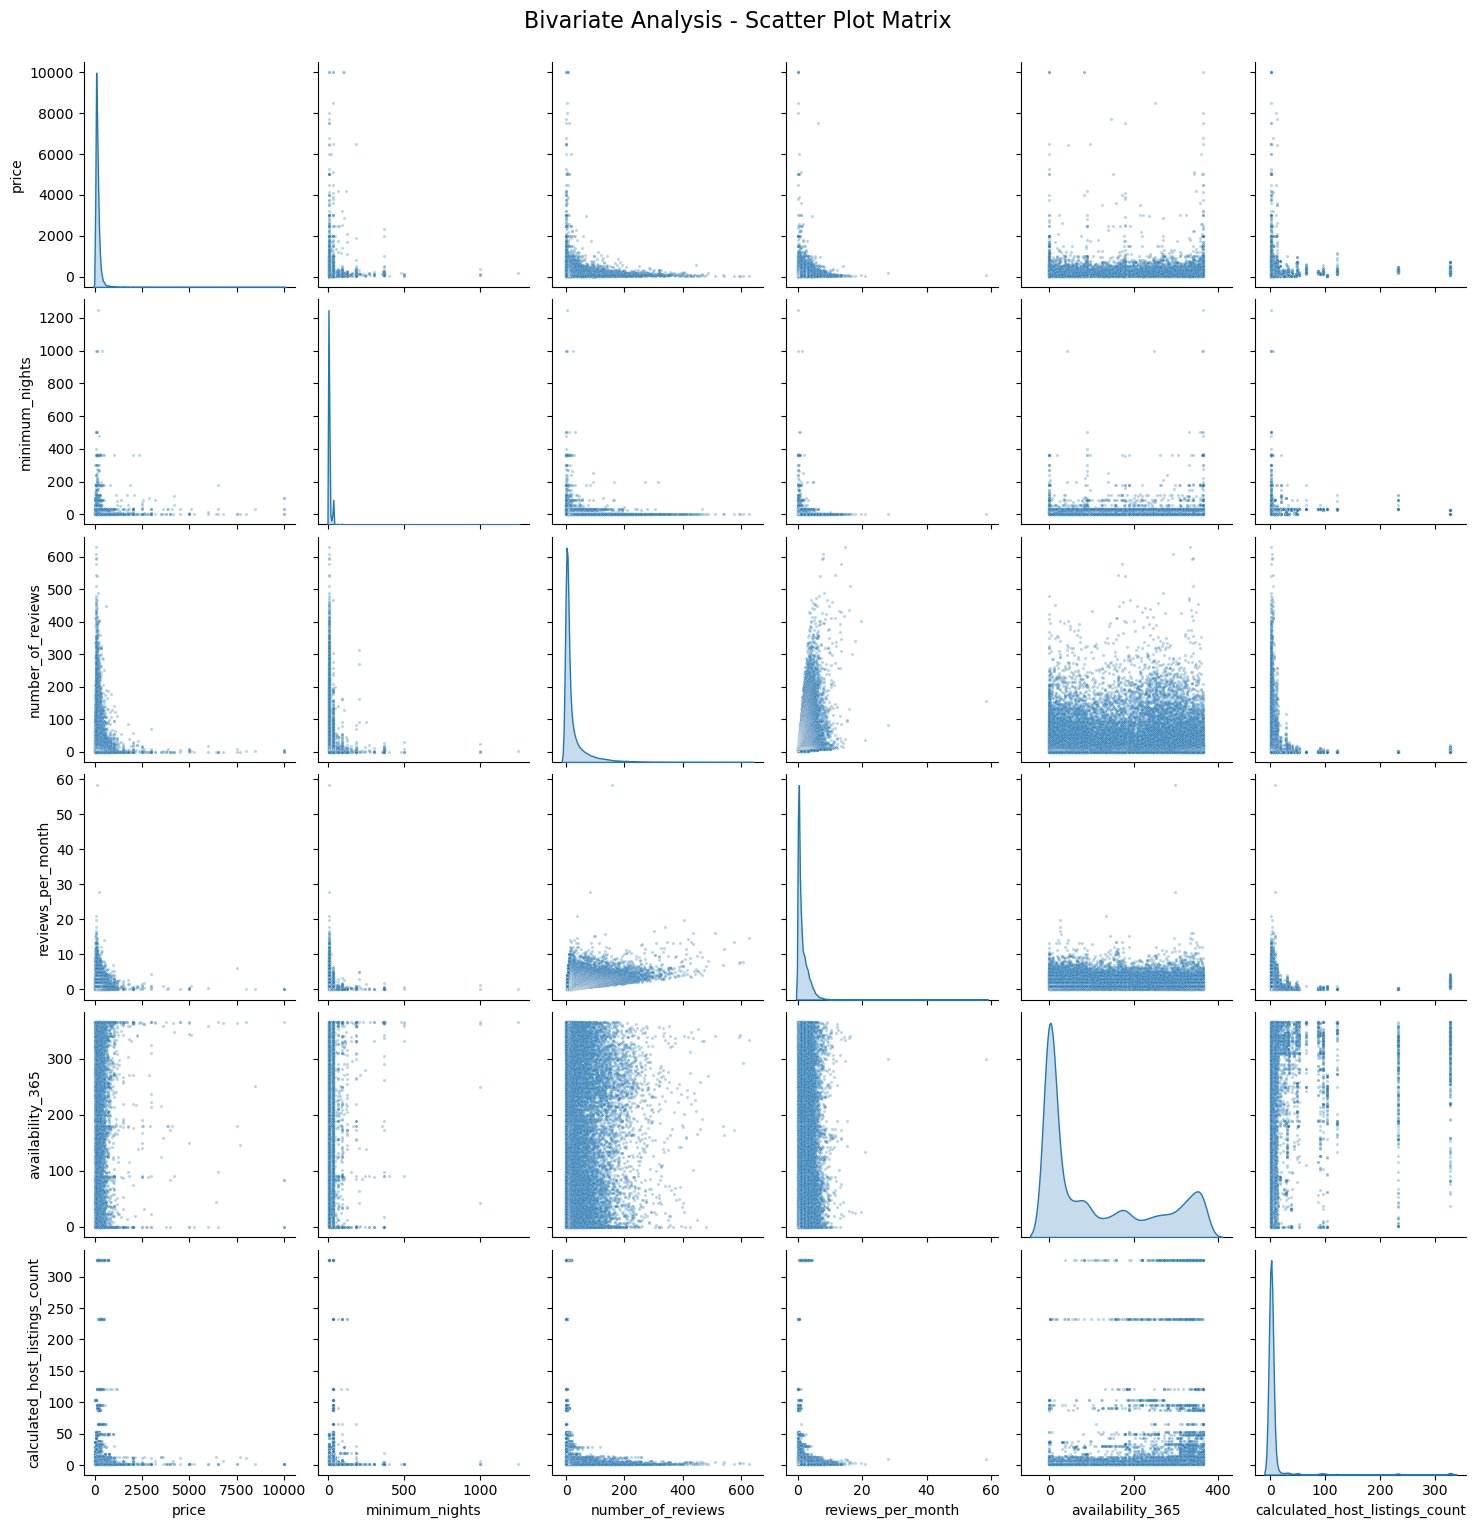

In [52]:
# ============================================================================
# BIVARIATE - Scatter plot matrix (pairplot) with all rows
# ============================================================================
sns.pairplot(pdf, diag_kind='kde', plot_kws={'alpha': 0.3, 's': 5})
plt.suptitle("Bivariate Analysis - Scatter Plot Matrix", fontsize=16, y=1.02)
plt.show()

## Errors Detected During EDA - Full Catalog

| # | Category | Column(s) | Description | Classification | Severity | Affected Rows | % | Examples | Impact | Remediation |
|---|----------|-----------|-------------|----------------|----------|---------------|-----|----------|--------|-------------|
| 1 | Format | name | Trailing whitespace in listing names | Actual Error | Medium | 236 | 0.48% | `'Charming West Village Apartment '` | Join mismatches, duplicate grouping | Auto-fix: trim whitespace |
| 2 | Format | name | Inconsistent capitalization in listing names | Business Anomaly | Low | 377 groups | — | `'Home Away From Home'` / `'HOME AWAY FROM HOME'` (6 variations) | Inconsistent grouping in reports | Flag for review: apply title case standardization |
| 3 | Format | host_name | Inconsistent capitalization in host names | Actual Error | Low | 24 groups | 0.05% | `MIchele` vs `Michele`, `FLora` vs `Flora` | Minor, mostly typos | Auto-fix: likely typos, flag for manual review |
| 4 | Format | name | Non-standard null representation (`'.'`) | Actual Error | Low | 1 | 0.002% | `'.'` | Counted as valid data instead of null | Auto-fix: replace with null |
| 5 | Format | name | Embedded newline characters in listing names | Actual Error | Medium | 168 | 0.34% | `'Cozy private room in NYC \n25 mins from Midtown'` | Parsing failures, export corruption | Auto-fix: remove/replace `\n` |
| 6 | Format | name | Embedded multi whitespaces in listing names | Actual Error | Low | 3+ | <0.01% | `'Huge 2 BR Upper East  Cental Park'` | Inconsistent text formatting, search/filter impact | Auto-fix: collapse multiple spaces |
| 7 | Accuracy | reviews_per_month | Range violation (>30 reviews/month max) | Actual Error | Low | 1 | 0.002% | `58.5` | Unrealistic review velocity | Auto-fix: flag for review, possible data error |
| 8 | Completeness | last_review, reviews_per_month | 20.56% missing values (coupled) | Edge Case | High | 10,052 | 20.56% | NULL when number_of_reviews=0 | Incomplete data but logically consistent | Accept as-is: MNAR pattern, expected when no reviews |
| 9 | Completeness | multiple | 15 rows with 3 missing values | Actual Error | Medium | 15 | 0.03% | — | Possible data entry failures | Flag for review: investigate these 15 rows |
| 10 | Completeness | last_review, reviews_per_month | MNAR pattern confirmed (missing when reviews=0) | Edge Case | Low | 10,052 | 20.56% | Varies by borough: Manhattan 23.22% | Expected behavior, document for context | Accept as-is: logically consistent missingness |
| 11 | Completeness | name, host_name | Isolated missing values, not correlated (MCAR) | Actual Error | Low | 16 (name), 21 (host_name) | 0.03–0.04% | Random missing names | Minor gaps, no correlation between columns | Flag for review: small volume, low priority |
| 12 | Consistency | minimum_nights, availability_365 | Min nights exceeds available days | Business Anomaly | High | 833 | 1.70% | min_nights=30, availability=9 days | Impossible bookings | Flag for review: may be valid for long-term rentals with limited calendar |
| 13 | Consistency | price, availability_365 | Available listings with $0 price | Business Anomaly | Medium | 8 | 0.02% | price=0, availability=28–333 days | Revenue reporting errors | Flag for review: possible data entry error or promotional listings |
| 14 | Consistency | price, room_type | Entire home/apt listed for $0 | Actual Error | High | 2 | 0.004% | Entire home/apt, price=0 | Broken business logic | Auto-fix: likely error, flag for correction |
| 15 | Consistency | price, availability_365 | Unavailable listings still priced | Edge Case | Low | 17,530 | 35.85% | price=$80, availability=0 | Inactive listings with residual pricing | Accept as-is: common for inactive listings, low impact |
| 16 | Consistency | reviews_per_month, number_of_reviews | Monthly rate disproportionate to total reviews | Business Anomaly | Medium | 6,412 | 13.11% | 58.5/month but only 156 total | May indicate recently active listings, not necessarily wrong | Flag for review: could be new highly popular listings |
| 17 | Consistency | host_id, host_name | Host IDs with no host name | Actual Error | Medium | 21 | 0.04% | host_id=526653, host_name=NULL | Broken host identification | Auto-fix: flag for data completion |
| 18 | Accuracy | price | Price outliers (>$873, 3σ above mean) | Business Anomaly | Medium | 388 | 0.79% | $10,000, $9,999, $8,500 | Skews averages, may be luxury valid | Flag for review: luxury listings may be legitimate |
| 19 | Accuracy | minimum_nights | Minimum nights outliers (>68, 3σ above mean) | Business Anomaly | Medium | 327 | 0.67% | 1,250, 1,000, 999 nights | Skews averages, may be long-term valid | Flag for review: long-term rentals may be legitimate |
| 20 | Accuracy | number_of_reviews | Review count outliers (>157, 3σ above mean) | Edge Case | Low | 1,221 | 2.50% | 629, 607, 597 reviews | Highly popular listings, not errors | Accept as-is: legitimate popular listings |
| 21 | Accuracy | reviews_per_month | Review rate outliers (>6.41/month, 3σ above mean) | Business Anomaly | Medium | 608 | 1.24% | 58.5, 27.95, 20.94/month | Unusually high review velocity | Flag for review: possible review manipulation or viral listings |
| 22 | Accuracy | calculated_host_listings_count | Host listing count outliers (>106, 3σ above mean) | Business Anomaly | Medium | 680 | 1.39% | 327 listings (multiple hosts) | Commercial operators vs individual hosts | Flag for review: legitimate property managers |
| 23 | Accuracy | price, minimum_nights, number_of_reviews | Severely skewed distributions (skew >2, kurtosis >7) | Edge Case | Low | All | 100% | price skew=19.12, min_nights skew=21.83 | Affects statistical modeling assumptions | Accept as-is: expected for marketplace data |
| 24 | Timeliness | N/A | Missing load/ingestion timestamp column | Actual Error | Medium | All | 100% | No ingestion_timestamp column | Cannot track data freshness or pipeline latency | Auto-fix: add ingestion_timestamp to Bronze layer |
| 25 | Timeliness | last_review | Temporal gaps in review activity (9 months) | Edge Case | Low | 9 months | — | 2011-06 through 2013-02 gaps | Minor gaps in early sparse data | Accept as-is: low review volume in early years |

---

## Stakeholder Escalation Required

| Issue # | Question for Stakeholder |
|---------|-------------------------|
| 2 | Should listing names be standardized to title case? |
| 12 | Are listings with min_nights > availability valid (long-term rentals with limited calendar)? |
| 13 | Are $0 listings promotional or data entry errors? |
| 18 | What is the maximum valid price per room type? Should luxury outliers be capped? |
| 19 | What is the maximum valid minimum_nights? Are 1,250-night listings valid? |
| 21 | Is unusually high reviews_per_month a concern (review manipulation)? |

---

## Summary by Classification

| Classification | Count | Action |
|----------------|-------|--------|
| Actual Error | 12 | Auto-fix or flag for correction |
| Business Anomaly | 8 | Escalate to stakeholder |
| Edge Case | 7 | Accept as-is, document |

---
